In [47]:
# commons
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# pipelines
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import (
    ColumnTransformer, 
    make_column_selector,
    TransformedTargetRegressor
)

# proprocessing
from sklearn.model_selection import (
    train_test_split,
    cross_val_predict, 
    cross_validate,
    KFold,
    GridSearchCV
)

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import (
    SelectPercentile, 
    chi2,
    RFECV,
    RFE
)
from sklearn.preprocessing import (
    FunctionTransformer,
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    PowerTransformer,
    QuantileTransformer,
    TargetEncoder
)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from scipy.sparse import hstack


# models
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    AdaBoostRegressor,
    StackingRegressor,
    HistGradientBoostingRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import (
    LinearRegression,
    RidgeCV,
    LassoCV,
)

# metrics
from sklearn.metrics import (
    PredictionErrorDisplay,
    median_absolute_error, 
    mean_squared_error,
    mean_squared_log_error,
    r2_score
)
from sklearn.inspection import permutation_importance

# saving
from tempfile import mkdtemp
from shutil import rmtree
cachedir = mkdtemp()
from joblib import Memory

# utils
import time

# configs
sns.set_theme(style="white")

In [2]:
import joblib

N_CORES = joblib.cpu_count(only_physical_cores=True)
print(f"Number of physical cores: {N_CORES}")

Number of physical cores: 16


# self note numerical data
1. compare different missing values imputation methods (drop all missing values, mean, mode, other statistical imputation)
    - GBR the best estimor yet handles missing values internally and is less computationally demanding than building complex estimator pipelines like Iterative imputers (https://scikit-learn.org/stable/auto_examples/impute/plot_iterative_imputer_variants_comparison.html#sphx-glr-auto-examples-impute-plot-iterative-imputer-variants-comparison-py)
3. compare different numerical transformation methods (no transformation, single data point vs whole feature transformation methods (minmax, power, robust))
4. compare different dimensionality reduction methods
    - conclusion: 
5. compare different algorithms (single, stacking)
    - approach: find the most likely model and maybe use it to finetune other parameters
    - conclusion: xgbost model is the best without stacking, stacking improves accuracy only fractionally)
6. compare different target transformation methods.
7. make a correlation plot of all numerical features
8. try target transformation and compare feature importance
    - target transform doesnt seem so helpful
10. check submission deadline -> 7th

# todo categorical

In [48]:
# Load the Train Parquet file for EDA
raw_train_df = pd.read_parquet("../datasets/raw_train_oct_2024.snappy.parquet")

print("Dataset loaded successfully!")
raw_train_df.iloc[:, :15].head(20)  # View first few rows

Dataset loaded successfully!


,stock_item_id,last_date_seen,first_date_seen,days_to_sell,first_retailer_asking_price,last_retailer_asking_price,can_home_deliver,reviews_per_100_advertised_stock_last_12_months,segment,seats,doors,co2_emission_gpkm,top_speed_mph,zero_to_sixty_mph_seconds,engine_power_bhp
0,b6598141a3d1dca4825a72e0f55ddfeb0fb55cabbc14da...,2024-10-12,2024-10-09,3,3695,3695,False,1.0,Independent,5.0,5.0,124.0,107.0,12.7,84.0
1,acdde4604ab932227b68abff979123a3f0b5d26d8b711e...,2024-10-11,2024-09-13,28,18998,18298,False,6.3,Franchise,5.0,5.0,130.0,119.0,None,129.0
2,0d29437822e059c038fc7f6385d9c348ba3727509add9a...,2024-10-05,2024-08-23,43,13990,13990,False,0.2,Independent,5.0,5.0,115.0,124.0,10.0,124.0
3,bbd82c7e47cba47f96ac59c7022ff1ca485c869f660778...,2024-10-15,2024-09-30,15,8174,7990,False,0.3,Independent,4.0,3.0,125.0,126.0,None,123.0
4,2515373efa5d36e0220cd42cc1cea23686e547cad17ca3...,2024-10-07,2024-08-15,53,9450,8750,False,7.3,Independent,5.0,5.0,146.0,120.0,None,123.0
5,cc8b1398b26941edd01b3280dda7a8fa4228a44fca127d...,2024-10-02,2024-09-04,28,7897,7897,False,4.4,Independent,5.0,5.0,158.0,109.0,11.8,110.0
6,10038453f1d28cf2d54764415b16831dbd4729005143c8...,2024-10-26,2024-10-01,25,23500,23000,False,0.7,Franchise,5.0,5.0,147.0,130.0,8.7,148.0
7,768836998ab25ca0284a4ac9aaf0b30c01dd6a1cdb1154...,2024-10-08,2024-09-26,12,10495,10495,False,45.0,Independent,4.0,2.0,124.0,140.0,None,187.0
8,14df89a70ac4058f6f65234a96ff50cfdfc0fcb42ffb4e...,2024-10-02,2024-09-27,5,5250,5250,False,4.6,Independent,5.0,5.0,193.0,110.0,None,148.0
9,ebbe035af17cd4ab562eb71e81da90633cc9b6ee6da588...,2024-10-29,2024-09-23,36,39000,39000,False,0.7,Independent,5.0,5.0,177.0,155.0,None,261.0


In [49]:

# Load the Test Parquet file for trained model testing
raw_test_df = pd.read_parquet("../datasets/raw_test_oct_2024.snappy.parquet")
print("Test Dataset loaded successfully!")
raw_test_df.head()

Test Dataset loaded successfully!


,stock_item_id,last_date_seen,first_date_seen,days_to_sell,first_retailer_asking_price,last_retailer_asking_price,can_home_deliver,reviews_per_100_advertised_stock_last_12_months,segment,seats,...,first_registration_date,attention_grabber,manufacturer_approved,price_indicator_rating,adjusted_retail_amount_gbp,predicted_mileage,number_of_images,first_image_label,advert_quality,postcode_area
0,0789d601c3d1418057fa319a23a163d7712f17961bd775...,2024-10-16,2024-09-30,16,3295,3295,False,22.3,Independent,5.0,...,2011-09-01,ONLY 41506 MILES F/S HISTORY,False,GOOD,3238.0,72777.0,66,FRONT_LEFT,32,DE
1,01f85662b4e5d0739decf02bac0ab97996287bfb1a6720...,2024-10-07,2024-10-04,3,16298,16298,False,11.0,Franchise,5.0,...,2019-11-05,Part-exchange offer now on,False,GOOD,15908.0,45974.0,19,INCONCLUSIVE,45,G
2,4c7daf0ae782e6216219fb368d8725a23abc541d6739de...,2024-10-30,2024-10-01,29,8380,8320,False,11.0,Franchise,5.0,...,2017-04-25,Apple Car Play | Android Auto,False,GREAT,8543.0,52486.0,2,FRONT_RIGHT,63,WN
3,22b562d576693c8db23f563bd55f11b9e25b0d0ca1ac42...,2024-10-30,2024-10-16,14,26990,26990,False,5.3,Independent,5.0,...,2017-06-30,PAN ROOF - IVORY HIDE,False,GREAT,27684.0,65833.0,61,FRONT_RIGHT,60,BL
4,880e451c2032086d78b84fa16cff78e7c643f0d52febf0...,2024-10-19,2024-09-25,24,47999,47949,False,NaN,Franchise,5.0,...,2022-10-31,LOW MILES HIGH SPEC,False,GOOD,48039.0,19381.0,30,FRONT_RIGHT,65,BT


In [4]:
raw_test_df.shape

(31136, 43)

In [5]:
X_train, y_train = (
    raw_train_df.drop(columns=['days_to_sell']), raw_train_df['days_to_sell'])

X_test, y_test = (
    raw_test_df.drop(columns=['days_to_sell']), raw_test_df['days_to_sell'])  # Target variable

# sample from the data
train_sample_size = 0.05
test_sample_size = 0.1

sampled_train_df = raw_train_df.sample(frac=train_sample_size, random_state=42)
X_train_sample, y_train_sample = (
    sampled_train_df.drop(columns=['days_to_sell']), sampled_train_df['days_to_sell'])

sampled_test_df = raw_test_df.sample(frac=test_sample_size, random_state=42)
X_test_sample, y_test_sample = (
    sampled_test_df.drop(columns=['days_to_sell']), sampled_test_df['days_to_sell'])


def print_data_summary(X_train, y_train, X_test, y_test, X_train_sample, y_train_sample, X_test_sample, y_test_sample):
    print("\n--- Data Summary ---")
    print(f"Train Set:      X: {X_train.shape}, y: {y_train.shape} (Total Samples: {len(X_train)})")
    print(f"Test Set:       X: {X_test.shape}, y: {y_test.shape} (Total Samples: {len(X_test)})")
    print(f"Sampled Train:  X: {X_train_sample.shape}, y: {y_train_sample.shape} (Samples: {len(X_train_sample)})")
    print(f"Sampled Test:   X: {X_test_sample.shape}, y: {y_test_sample.shape} (Samples: {len(X_test_sample)})")
    
# Call the function with your datasets
print_data_summary(X_train, y_train, X_test, y_test, X_train_sample, y_train_sample, X_test_sample, y_test_sample)



--- Data Summary ---
Train Set:      X: (112086, 42), y: (112086,) (Total Samples: 112086)
Test Set:       X: (31136, 42), y: (31136,) (Total Samples: 31136)
Sampled Train:  X: (5604, 42), y: (5604,) (Samples: 5604)
Sampled Test:   X: (3114, 42), y: (3114,) (Samples: 3114)


## Transformation pipeline utils

In [9]:
DEFAULT_COLS_DROP = ["stock_item_id", "last_date_seen", "first_date_seen", "derivative_id", "first_registration_date"]
DEFAULT_ZERO_NUM_FEATURES = ['battery_range_miles', 'battery_usable_capacity_kwh']
DEFAULT_NON_ZERO_NUM_FEATURES = ['first_retailer_asking_price',
 'last_retailer_asking_price',
 'reviews_per_100_advertised_stock_last_12_months',
 'seats',
 'doors',
 'co2_emission_gpkm',
 'top_speed_mph',
 'zero_to_sixty_mph_seconds',
 'engine_power_bhp',
 'fuel_economy_wltp_combined_mpg',
 'length_mm',
 'boot_space_seats_up_litres',
 'insurance_group',
 'plate',
 'odometer_reading_miles',
 'adjusted_retail_amount_gbp',
 'predicted_mileage',
 'number_of_images',
 'advert_quality']

In [10]:
# Replace None with Nan Transformer.
def replace_none_with_nan(df: pd.DataFrame) -> pd.DataFrame:
    """Replaces None with np.nan in categorical columns."""
    df = df.copy()
    categorical_cols = df.select_dtypes(include=['object']).columns
    df[categorical_cols] = df[categorical_cols].apply(lambda col: col.map(lambda x: np.nan if x is None else x))
    return df


def drop_features(df: pd.DataFrame) -> pd.DataFrame:
    """Drop features not required"""
    df = df.copy()
    columns_to_drop = DEFAULT_COLS_DROP
    return df.drop(columns=columns_to_drop, errors='ignore')


def convert_columns_to_numeric(df: pd.DataFrame) -> pd.DataFrame:
    """Converts specified object columns to float/numeric type without dropping them."""
    df = df.copy()
    
    convert_columns = ["zero_to_sixty_mph_seconds", "engine_power_bhp", "fuel_economy_wltp_combined_mpg",
                       "battery_usable_capacity_kwh", "length_mm", "insurance_group", "plate"]
    
    # Ensure we only select columns that exist in the DataFrame
    existing_columns = list(set(df.columns) & set(convert_columns))
    
    if existing_columns:  # Only apply conversion if columns exist
        df[existing_columns] = df[existing_columns].apply(pd.to_numeric, errors='coerce')

    return df


def compute_score(y_true, y_pred):
    return {
        "R2": f"{r2_score(y_true, y_pred):.3f}",
        "MedAE": f"{median_absolute_error(y_true, y_pred):.3f}",
    }

Data Processing pipelines

In [11]:
# Data preprocessing pipeline
data_preparation_pipeline = Pipeline([
    ('drop_columns', FunctionTransformer(drop_features)), # Drop id and date columns
    ('replace_none', FunctionTransformer(replace_none_with_nan, validate=False)),  # Custom transformer to handle 'None'
    ('convert_2numeric', FunctionTransformer(convert_columns_to_numeric))
])

Numerical pipelines

In [13]:
# Numerical Column transformer
numerical_transformer = ColumnTransformer(
    transformers=[
        ('zero_impute', SimpleImputer(
            strategy='constant', fill_value=0), DEFAULT_ZERO_NUM_FEATURES), # Zero imputation for specific columns
        ('imputation', SimpleImputer(strategy='mean'), DEFAULT_NON_ZERO_NUM_FEATURES) # Mean imputation for other numerical columns
    ]
)

# Numerical pipeline
numeric_pipeline = Pipeline([
    ('imputer', numerical_transformer),  # Handle missing values
    ('scaler', PowerTransformer(method="yeo-johnson"))  # Scale numeric features
])

Combined numerical and Categorical Pipeline

In [15]:
columns_preprocessor = ColumnTransformer([
    ('numeric_features', numeric_pipeline, make_column_selector(dtype_include=np.number)),
    #('categorical_features', categorical_pipeline, make_column_selector(dtype_include=["object", "bool"]))
])

Regression models configuration

In [16]:
rng = np.random.RandomState(1)

In [20]:
# model definition
dt = DecisionTreeRegressor()
svr = SVR(kernel="linear")
rf = RandomForestRegressor(random_state=42)
laso_cv = LassoCV()
gbr = HistGradientBoostingRegressor(random_state=0)

dt_regr2 = AdaBoostRegressor(
    DecisionTreeRegressor(), n_estimators=300, random_state=rng
)

In [21]:
# random forest models
rf_notrans = RandomForestRegressor()
rf_trans = TransformedTargetRegressor(regressor=rf_notrans,
                                  transformer=QuantileTransformer(output_distribution='normal')
                                 )

Feature Selector

In [65]:
min_features_to_select = 1  # Minimum number of features to consider
cv = KFold(5, shuffle=True, random_state=42)

rfecv_best = RFECV(
    estimator=rf,
    step=1,
    cv=cv,
    scoring="r2",
    min_features_to_select=min_features_to_select,
    n_jobs=-1,
)

In [152]:
quantile_transform = QuantileTransformer(output_distribution='normal')
power_transformer = PowerTransformer()


In [25]:
# target transformation experiment
final_pipeline_notrans = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('regressor_pipeline', rf_notrans)
])

# Final pipeline combining the preprocessor and classifier
final_pipeline_trans = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('regressor_pipeline', rf_trans)
])


## Model Stacking pipeline Experiment

In [63]:
# stacking models with no transformations
lasso_pipeline = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('regressor_pipeline', svr)
])

rf_pipeline = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('regressor_pipeline', rf)
])

gbdt_pipeline = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('regressor_pipeline', gbr)
])

estimators = [
    ("Random Forest", rf_pipeline),
    ("Lasso", lasso_pipeline),
    ("Gradient Boosting", gbdt_pipeline),
]

stacking_regressor = StackingRegressor(estimators=estimators, final_estimator=RidgeCV())
stacking_regressor

StackingRegressor(estimators=[('Random Forest',
                               Pipeline(steps=[('data_preparation',
                                                Pipeline(steps=[('drop_columns',
                                                                 FunctionTransformer(func=<function drop_features at 0x73cfc4d6ade0>)),
                                                                ('replace_none',
                                                                 FunctionTransformer(func=<function replace_none_with_nan at 0x73cfc4d6ac00>)),
                                                                ('convert_2numeric',
                                                                 FunctionTransformer(func=<function convert_columns_to_numer...
                                                                                                                                    'insurance_group',
                                                                                                                                    'plate',
                                                                                                                                    'odometer_reading_miles',
                                                                                                                                    'adjusted_retail_amount_gbp',
                                                                                                                                    'predicted_mileage',
                                                                                                                                    'number_of_images',
                                                                                                                                    'advert_quality'])])),
                                                                                                 ('scaler',
                                                                                                  PowerTransformer())]),
                                                                                 <sklearn.compose._column_transformer.make_column_selector object at 0x73cfd0082490>)])),
                                               ('regressor_pipeline',
                                                HistGradientBoostingRegressor(random_state=0))]))],
                  final_estimator=RidgeCV())

In [95]:
X.shape

(3363, 42)

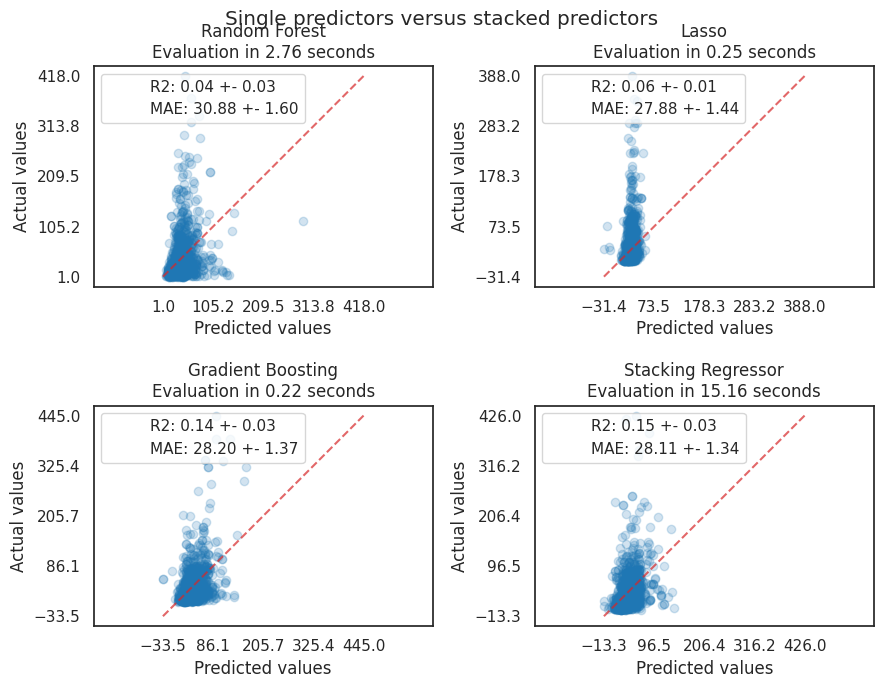

In [122]:
# X.shape -> (3363, 42)
fig, axs = plt.subplots(2, 2, figsize=(9, 7))
axs = np.ravel(axs)

for ax, (name, est) in zip(
    axs, estimators + [("Stacking Regressor", stacking_regressor)]
):
    scorers = {"R2": "r2", "MAE": "neg_mean_absolute_error"}

    start_time = time.time()
    scores = cross_validate(
        est, X, y, scoring=list(scorers.values()), n_jobs=-1, verbose=0
    )
    elapsed_time = time.time() - start_time

    y_pred = cross_val_predict(est, X, y, n_jobs=-1, verbose=0)
    scores = {
        key: (
            f"{np.abs(np.mean(scores[f'test_{value}'])):.2f} +- "
            f"{np.std(scores[f'test_{value}']):.2f}"
        )
        for key, value in scorers.items()
    }

    display = PredictionErrorDisplay.from_predictions(
        y_true=y,
        y_pred=y_pred,
        kind="actual_vs_predicted",
        ax=ax,
        scatter_kwargs={"alpha": 0.2, "color": "tab:blue"},
        line_kwargs={"color": "tab:red"},
    )
    ax.set_title(f"{name}\nEvaluation in {elapsed_time:.2f} seconds")

    for name, score in scores.items():
        ax.plot([], [], " ", label=f"{name}: {score}")
    ax.legend(loc="upper left")

plt.suptitle("Single predictors versus stacked predictors")
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

## Recursive Feature Elimination Stacking feature Experiment

DecisionTreeRegressor Optimal number of features: 2
SVR Optimal number of features: 13
RandomForestRegressor Optimal number of features: 2
LassoCV Optimal number of features: 21


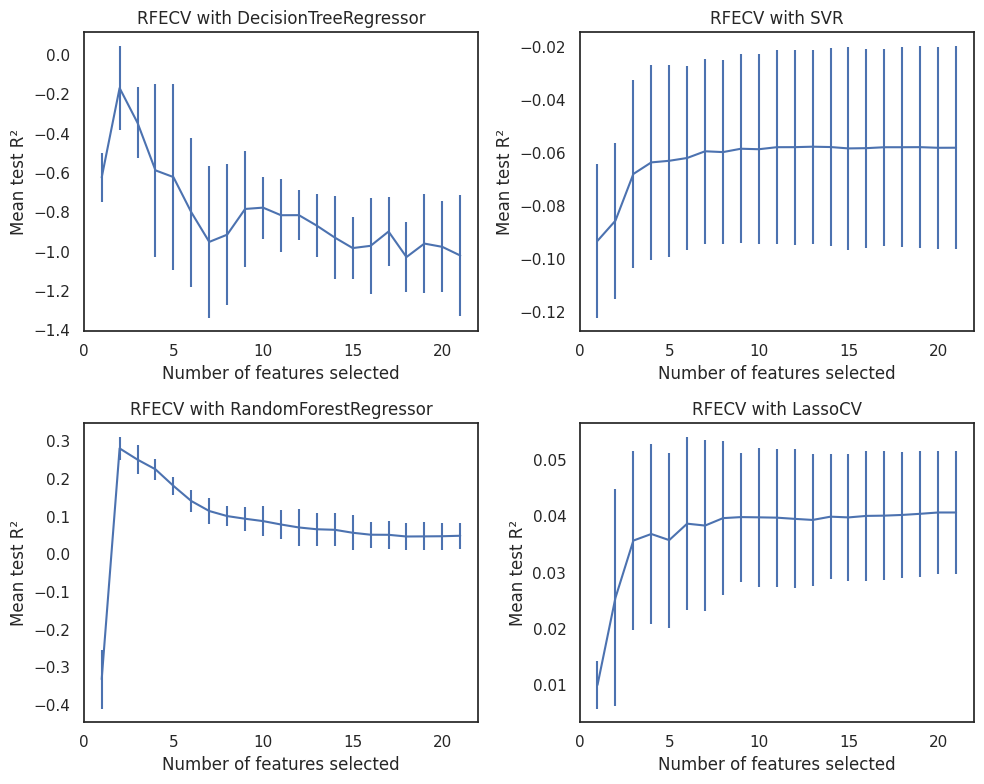

In [128]:
# models
dt = DecisionTreeRegressor()
svr = SVR(kernel="linear")
rf = RandomForestRegressor(random_state=42)
lasso_cv = LassoCV()

models = [dt, svr, rf, lasso_cv]

# Minimum number of features
min_features_to_select = 1  
cv = KFold(5, shuffle=True, random_state=42)

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs = np.ravel(axs)  # Flatten the 2x2 grid

for i, model in enumerate(models):
    rfecv = RFECV(
        estimator=model,
        step=1,
        cv=cv,
        scoring="r2",
        min_features_to_select=min_features_to_select,
        n_jobs=-1,
    )

    # Fit RFECV
    rfecv.fit(gbdt_pipeline[:-1].fit_transform(X), y)

    print(f"{model.__class__.__name__} Optimal number of features: {rfecv.n_features_}")

    # Extract CV results
    cv_results = pd.DataFrame(rfecv.cv_results_)

    # Plot on corresponding subplot
    axs[i].errorbar(
        x=cv_results["n_features"],
        y=cv_results["mean_test_score"],
        yerr=cv_results["std_test_score"],
    )
    axs[i].set_xlabel("Number of features selected")
    axs[i].set_ylabel("Mean test R²")
    axs[i].set_title(f"RFECV with {model.__class__.__name__}")

plt.tight_layout()
plt.show()


Sample all data to determine the informative features from the best models using RFECV

In [153]:
X_train.shape, X_train_sample.shape, X_test_sample.shape

((112086, 42), (11209, 42), (3114, 42))

In [64]:
#rfecv_best.fit(gbdt_pipeline[:-1].fit_transform(X_train_sample), y_train_sample)

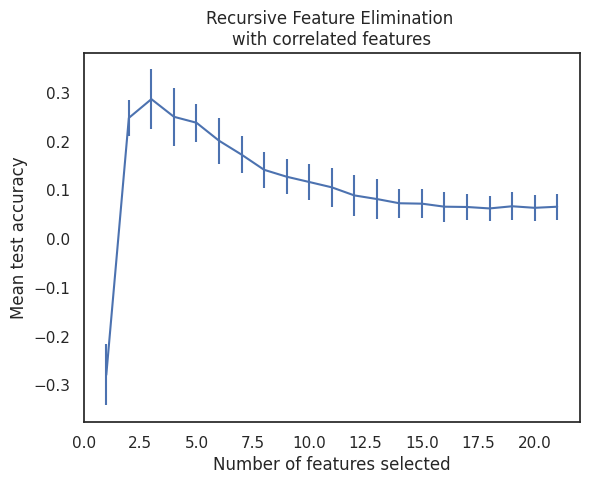

In [159]:
cv_results = pd.DataFrame(rfecv_best.cv_results_)
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Mean test accuracy")
plt.errorbar(
    x=cv_results["n_features"],
    y=cv_results["mean_test_score"],
    yerr=cv_results["std_test_score"],
)
plt.title("Recursive Feature Elimination \nwith correlated features")
plt.show()

In [161]:
print(f"Optimal number of features: {rfecv_best.n_features_}")
rfecv_best.ranking_

Optimal number of features: 3


array([18, 19,  1,  1,  7, 17, 16,  5, 14, 13, 10, 11,  6,  8, 15, 12,  3,
        1,  2,  4,  9])

Test recursive feature stacking in pipeline

In [177]:
rf_pipeline_rfe = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('rfe', rfecv_best),
    ('regressor_pipeline', rf)
])

gbdt_pipeline_rfe = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('rfe', rfecv_best),
    ('regressor_pipeline', gbr)
])

In [178]:
gbdt_pipeline_rfe

Pipeline(steps=[('data_preparation',
                 Pipeline(steps=[('drop_columns',
                                  FunctionTransformer(func=<function drop_cat_features at 0x7591078ef740>)),
                                 ('replace_none',
                                  FunctionTransformer(func=<function replace_none_with_nan at 0x7591078ec540>)),
                                 ('convert_2numeric',
                                  FunctionTransformer(func=<function convert_columns_to_numeric at 0x7591078edee0>))])),
                ('data_preprocess...
                                                                                                     'number_of_images',
                                                                                                     'advert_quality'])])),
                                                                  ('scaler',
                                                                   PowerTransformer())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x759107eb7910>)])),
                ('rfe',
                 RFECV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                       estimator=RandomForestRegressor(random_state=42),
                       n_jobs=-1, scoring='r2')),
                ('regressor_pipeline',
                 HistGradientBoostingRegressor(random_state=0))])

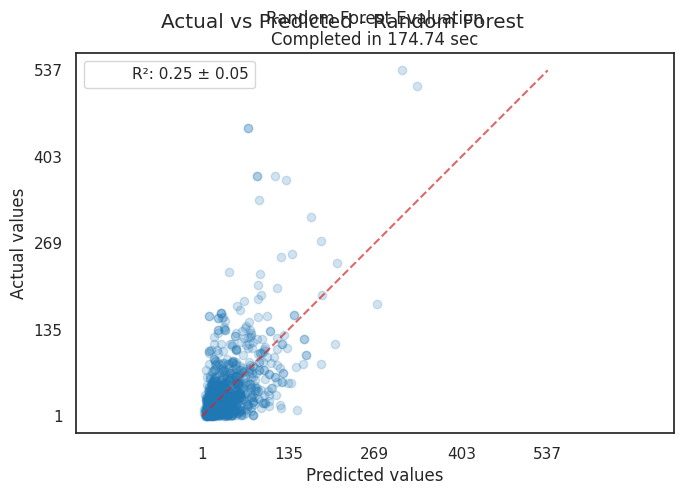

In [172]:
# Fit the Random Forest pipeline
rf_pipeline_rfe.fit(X_train_sample, y_train_sample)

# Define the single R² scoring metric
scoring_metric = "r2"

# Cross-validation and timing
start_time = time.time()
scores = crosrs_validate(
    rf_pipeline_rfe, X_train_sample, y_train_sample, scoring=scoring_metric, n_jobs=-1, verbose=0
)
elapsed_time = time.time() - start_time

# Get cross-validated predictions
y_pred = cross_val_predict(rf_pipeline_rfe, X_test_sample, y_test_sample, n_jobs=-1, verbose=0)

# Compute R² score mean and standard deviation
r2_mean = np.mean(scores["test_score"])
r2_std = np.std(scores["test_score"])
r2_score_text = f"R²: {r2_mean:.2f} ± {r2_std:.2f}"

# Initialize plot
fig, ax = plt.subplots(figsize=(7, 5))

# Plot actual vs predicted
display = PredictionErrorDisplay.from_predictions(
    y_true=y_test_sample,
    y_pred=y_pred,
    kind="actual_vs_predicted",
    ax=ax,
    scatter_kwargs={"alpha": 0.2, "color": "tab:blue"},
    line_kwargs={"color": "tab:red"},
)
ax.set_title(f"Random Forest Evaluation\nCompleted in {elapsed_time:.2f} sec")

# Add R² score to legend
ax.plot([], [], " ", label=r2_score_text)
ax.legend(loc="upper left")

# Display plot
plt.suptitle("Actual vs Predicted - Random Forest")
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()


## Comparing RF vs GB with future selection

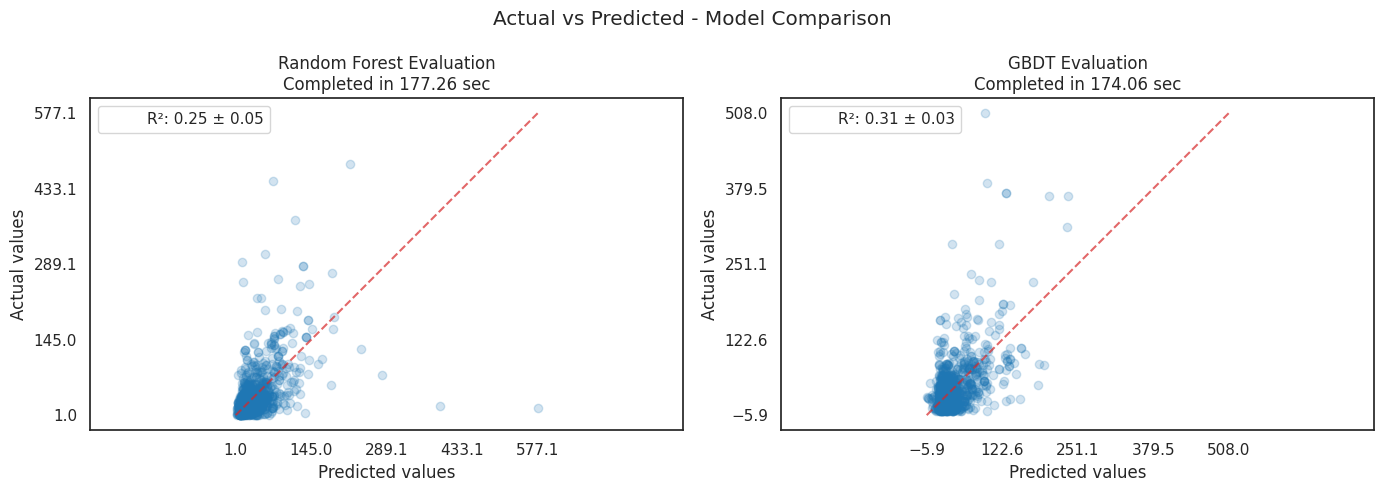

In [180]:
# Define models
models = {
    "Random Forest": rf_pipeline_rfe,
    "GBDT": gbdt_pipeline_rfe,
}

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, models.items()):
    # Fit the model
    model.fit(X_train_sample, y_train_sample)

    # Cross-validation and timing
    start_time = time.time()
    scores = cross_validate(model, X_train_sample, y_train_sample, scoring="r2", n_jobs=-1, verbose=0)
    elapsed_time = time.time() - start_time

    # Get cross-validated predictions
    y_pred = cross_val_predict(model, X_test_sample, y_test_sample, n_jobs=-1, verbose=0)

    # Compute R² score mean and standard deviation
    r2_mean = np.mean(scores["test_score"])
    r2_std = np.std(scores["test_score"])
    r2_score_text = f"R²: {r2_mean:.2f} ± {r2_std:.2f}"

    # Plot actual vs predicted
    PredictionErrorDisplay.from_predictions(
        y_true=y_test_sample,
        y_pred=y_pred,
        kind="actual_vs_predicted",
        ax=ax,
        scatter_kwargs={"alpha": 0.2, "color": "tab:blue"},
        line_kwargs={"color": "tab:red"},
    )
    
    ax.set_title(f"{name} Evaluation\nCompleted in {elapsed_time:.2f} sec")

    # Add R² score to legend
    ax.plot([], [], " ", label=r2_score_text)
    ax.legend(loc="upper left")

# Display plots
plt.suptitle("Actual vs Predicted - Model Comparison")
plt.tight_layout()
plt.show()


## Feature Importance

Numerical feature importance

In [29]:
rf_pipeline_num = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('regressor_pipeline', rf)
])

In [30]:
rf_pipeline_num.fit(X_train_sample, y_train_sample)

Pipeline(steps=[('data_preparation',
                 Pipeline(steps=[('drop_columns',
                                  FunctionTransformer(func=<function drop_features at 0x73cfc4d6ade0>)),
                                 ('replace_none',
                                  FunctionTransformer(func=<function replace_none_with_nan at 0x73cfc4d6ac00>)),
                                 ('convert_2numeric',
                                  FunctionTransformer(func=<function convert_columns_to_numeric at 0x73cfc4d6af20>))])),
                ('data_preprocessor',...
                                                                                                     'boot_space_seats_up_litres',
                                                                                                     'insurance_group',
                                                                                                     'plate',
                                                                                                     'odometer_reading_miles',
                                                                                                     'adjusted_retail_amount_gbp',
                                                                                                     'predicted_mileage',
                                                                                                     'number_of_images',
                                                                                                     'advert_quality'])])),
                                                                  ('scaler',
                                                                   PowerTransformer())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x73cfd0082490>)])),
                ('regressor_pipeline', RandomForestRegressor(random_state=42))])

In [293]:
# rf_pipeline_rfe.fit(X_train_sample, y_train_sample)
# print(f'Train score {rf_pipeline_rfe.score(X_train_sample, y_train_sample)}')
# print(f'Test score {rf_pipeline_rfe.score(X_test_sample, y_test_sample)}')

Train score 0.8956299939123494
Test score 0.30101318243300546


In [32]:
print(f'Train score {rf_pipeline_num.score(X_train_sample, y_train_sample)}')
print(f'Test score {rf_pipeline_num.score(X_test_sample, y_test_sample)}')

Train score 0.8705355420306875
Test score 0.1463925815212096


In [33]:
X_train_sample.shape

(5604, 42)

In [34]:
feature_names = rf_pipeline_num.named_steps["data_preprocessor"].get_feature_names_out()
feature_importance = rf_pipeline_num[-1].feature_importances_

mdi_importances = pd.Series(
    feature_importance, index=feature_names
).sort_values(ascending=True)

/tmp/ipykernel_8213/1347216174.py:3: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  ax.figure.tight_layout()


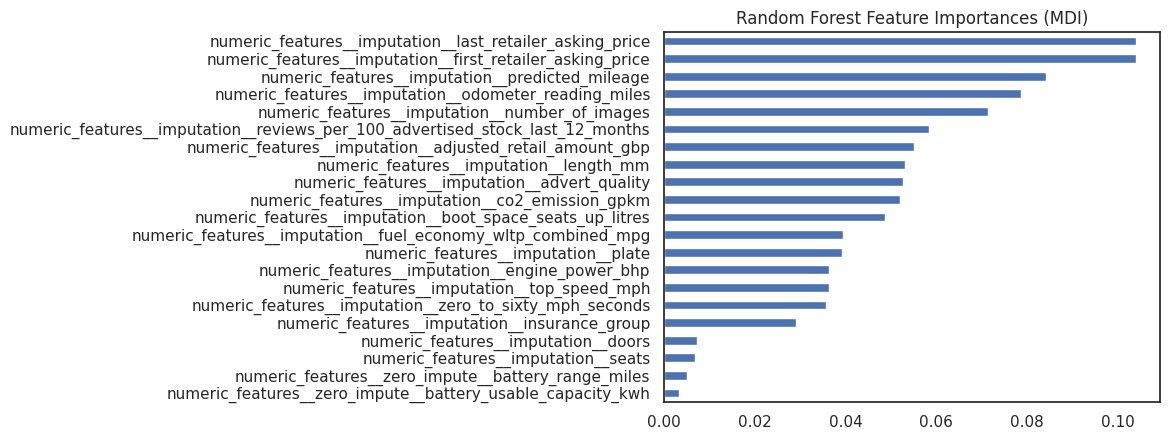

In [35]:
ax = mdi_importances.plot.barh()
ax.set_title("Random Forest Feature Importances (MDI)")
ax.figure.tight_layout()

In [39]:
feature_importance

array([0.00500379, 0.00325659, 0.10385613, 0.10396966, 0.05828129,
       0.0067529 , 0.00723019, 0.05189359, 0.03631923, 0.03570707,
       0.03640814, 0.03933802, 0.05318152, 0.04862665, 0.02902432,
       0.03911296, 0.07869959, 0.05507375, 0.08422042, 0.07137555,
       0.05266865])

In [40]:
sorted_idx

array([ 1,  0,  5,  6, 14,  9,  8, 10, 15, 11, 13,  7, 20, 12, 17,  4, 19,
       16, 18,  2,  3])

In [41]:
sorted_perm_idx

array([ 1,  0,  5,  6, 14, 11,  8, 20,  4, 15,  9,  7, 10, 13, 12, 17, 18,
       19, 16,  3,  2])

In [53]:
feature_names = rf_pipeline_num[:2].set_output(transform='pandas').fit_transform(X_train_sample).columns

In [59]:
# Ensure DEFAULT_COLS_DROP is defined or remove it if not needed
df = X_train_sample.copy()
df_new = df.drop(DEFAULT_COLS_DROP, axis=1) if "DEFAULT_COLS_DROP" in globals() else df

# Extract feature importance from the final model in the pipeline
rf_model = rf_pipeline_num.named_steps["regressor_pipeline"]

# Compute MDI feature importance
feature_importance = rf_model.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(len(sorted_idx)) + 0.5

# Compute permutation importance
# result = permutation_importance(
#     rf_model, rf_pipeline_num[:-1].fit_transform(df_new),
#     y_train_sample, n_repeats=10, random_state=42, n_jobs=-1
# )
# sorted_perm_idx = result.importances_mean.argsort()

# # Create side-by-side subplots
# fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# # Plot MDI Feature Importance
# axes[0].barh(pos, feature_names[sorted_idx], align="center", color="royalblue")
# axes[0].set_yticks(pos)
# axes[0].set_yticklabels(feature_names[sorted_idx])
# axes[0].set_title("Feature Importance (MDI)")
# axes[0].set_xlabel("Mean Decrease in Impurity")


# # Plot Permutation Importance
# tick_labels_dict = {"tick_labels": feature_names[sorted_perm_idx]}
# axes[1].boxplot(result.importances[sorted_perm_idx].T, vert=False, **tick_labels_dict)
# axes[1].set_title("Permutation Importance (Test Set)")

# # Adjust layout and show plots
# plt.tight_layout()
# plt.show()


Top features with RFE

In [319]:
gbdt_pipeline_rfe.fit(X_train_sample, y_train_sample)
print(f'Train score {gbdt_pipeline_rfe.score(X_train_sample, y_train_sample)}')
print(f'Test score {gbdt_pipeline_rfe.score(X_test_sample, y_test_sample)}')

Train score 0.5114481978250836
Test score 0.3490185760405403


In [318]:
rf_pipeline_num_rfe = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('rfe', rfecv_best),
    ('regressor_pipeline', rf)
])

rf_pipeline_num_rfe.fit(X_train_sample, y_train_sample)
print(f'Train score {rf_pipeline_num_rfe.score(X_train_sample, y_train_sample)}')
print(f'Test score {rf_pipeline_num_rfe.score(X_test_sample, y_test_sample)}')

Train score 0.8956299939123494
Test score 0.30101318243300546


# Target transformation Experiment

## GB on target transformation

In [ ]:
gbr_transform = TransformedTargetRegressor(
    regressor=gbr,
    func=np.log1p,         
    inverse_func=np.expm1
)

In [66]:

gbr_pipeline_num_trans = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('rfe', rfecv_best),
    ('regressor_pipeline', gbr_transform)
])

gbr_pipeline_num_trans.fit(X_train_sample, y_train_sample)
print(f'Train score {gbr_pipeline_num_trans.score(X_train_sample, y_train_sample)}')
print(f'Test score {gbr_pipeline_num_trans.score(X_test_sample, y_test_sample)}')

Train score 0.3617000679949124
Test score 0.25290026442994507


In [67]:
gbr_pipeline_num_trans = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    #('rfe', rfecv_best),
    ('regressor_pipeline', gbr_transform)
])

gbr_pipeline_num_trans.fit(X_train_sample, y_train_sample)
print(f'Train score {gbr_pipeline_num_trans.score(X_train_sample, y_train_sample)}')
print(f'Test score {gbr_pipeline_num_trans.score(X_test_sample, y_test_sample)}')

Train score 0.3806411431242298
Test score 0.12322394823637128


In [68]:
gbr_pipeline_num_trans = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    #('rfe', rfecv_best),
    ('regressor_pipeline', gbr)
])

gbr_pipeline_num_trans.fit(X_train_sample, y_train_sample)
print(f'Train score {gbr_pipeline_num_trans.score(X_train_sample, y_train_sample)}')
print(f'Test score {gbr_pipeline_num_trans.score(X_test_sample, y_test_sample)}')

Train score 0.6627132491180335
Test score 0.262765541374156


In [153]:
quantile_transform = QuantileTransformer(output_distribution='normal')
power_transformer = PowerTransformer()

model_target_trans = TransformedTargetRegressor(
    regressor=gbr,
    transformer=QuantileTransformer(n_quantiles=900, output_distribution="normal"),
)

target_trans_pipeline = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('rfe', rfecv_best),
    ('regressor_pipeline', model_target_trans)
])

target_trans_pipeline.fit(X_train_sample, y_train_sample)
print(f'Train score {target_trans_pipeline.score(X_train_sample, y_train_sample)}')
print(f'Test score {target_trans_pipeline.score(X_test_sample, y_test_sample)}')

Train score 0.3708994272217012
Test score 0.272488145816544


In [69]:
gbr_pipeline_num_trans = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('rfe', rfecv_best),
    ('regressor_pipeline', gbr)
])

gbr_pipeline_num_trans.fit(X_train_sample, y_train_sample)
print(f'Train score {gbr_pipeline_num_trans.score(X_train_sample, y_train_sample)}')
print(f'Test score {gbr_pipeline_num_trans.score(X_test_sample, y_test_sample)}')

Train score 0.5114481978250836
Test score 0.3490185760405403


In [72]:
# Define models with different configurations
models = {
    "GBR + RFE + Log Transform": Pipeline([
        ('data_preparation', data_preparation_pipeline),
        ('data_preprocessor', columns_preprocessor),
        ('rfe', rfecv_best),
        ('regressor_pipeline', TransformedTargetRegressor(
            regressor=gbr, func=np.log1p, inverse_func=np.expm1))
    ]),
    
    "GBR + Log Transform": Pipeline([
        ('data_preparation', data_preparation_pipeline),
        ('data_preprocessor', columns_preprocessor),
        # No RFE
        ('regressor_pipeline', TransformedTargetRegressor(
            regressor=gbr, func=np.log1p, inverse_func=np.expm1))
    ]),
    
    "GBR Only": Pipeline([
        ('data_preparation', data_preparation_pipeline),
        ('data_preprocessor', columns_preprocessor),
        # No RFE
        ('regressor_pipeline', gbr)  # No transformation
    ]),
    
    "GBR + RFE": Pipeline([
        ('data_preparation', data_preparation_pipeline),
        ('data_preprocessor', columns_preprocessor),
        ('rfe', rfecv_best),
        ('regressor_pipeline', gbr)  # No transformation
    ])
}

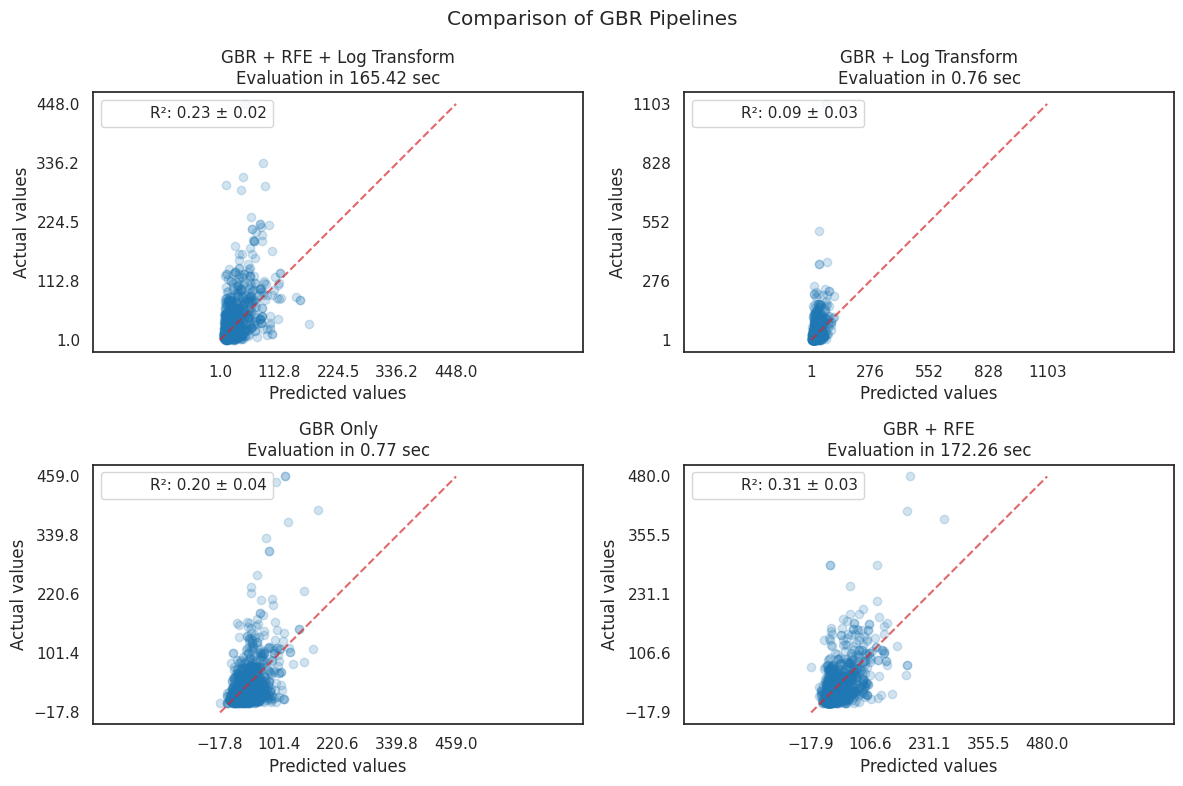

In [73]:
# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = np.ravel(axs)  # Flatten the 2x2 subplot grid

for ax, (name, pipeline) in zip(axs, models.items()):
    # Cross-validation scoring
    scorers = {"R2": "r2"}
    
    start_time = time.time()
    scores = cross_validate(
        pipeline, X_train_sample, y_train_sample, 
        scoring=scorers, n_jobs=-1, verbose=0
    )
    elapsed_time = time.time() - start_time
    
    # Get cross-validated predictions
    y_pred = cross_val_predict(pipeline, X_test_sample, y_test_sample, n_jobs=-1, verbose=0)

    # Compute mean R² score
    r2_mean = np.mean(scores["test_R2"])
    r2_std = np.std(scores["test_R2"])
    r2_score_text = f"R²: {r2_mean:.2f} ± {r2_std:.2f}"

    # Plot actual vs predicted
    PredictionErrorDisplay.from_predictions(
        y_true=y_test_sample,
        y_pred=y_pred,
        kind="actual_vs_predicted",
        ax=ax,
        scatter_kwargs={"alpha": 0.2, "color": "tab:blue"},
        line_kwargs={"color": "tab:red"},
    )

    ax.set_title(f"{name}\nEvaluation in {elapsed_time:.2f} sec")

    # Add R² score to legend
    ax.plot([], [], " ", label=r2_score_text)
    ax.legend(loc="upper left")

# Adjust layout
plt.suptitle("Comparison of GBR Pipelines")
plt.tight_layout()
plt.show()

In [80]:
y_pred_trans = models["GBR + RFE + Log Transform"].fit(X_train_sample, y_train_sample).predict(X_test_sample)
y_pred_notrans = models['GBR + RFE'].fit(X_train_sample, y_train_sample).predict(X_test_sample)

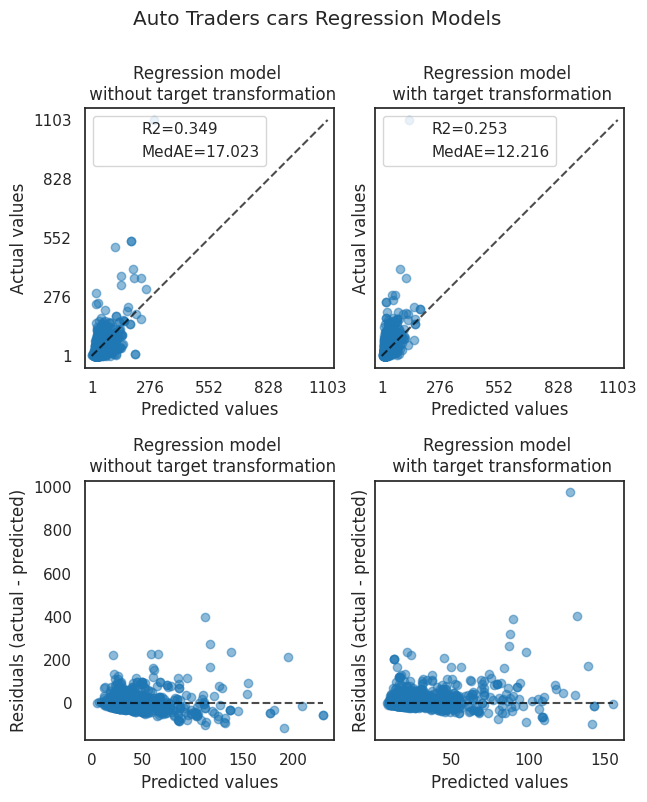

In [81]:

f, (ax0, ax1) = plt.subplots(2, 2, sharey="row", figsize=(6.5, 8))

# plot the actual vs predicted values
PredictionErrorDisplay.from_predictions(
    y_test_sample,
    y_pred_notrans,
    kind="actual_vs_predicted",
    ax=ax0[0],
    scatter_kwargs={"alpha": 0.5},
)
PredictionErrorDisplay.from_predictions(
    y_test_sample,
    y_pred_trans,
    kind="actual_vs_predicted",
    ax=ax0[1],
    scatter_kwargs={"alpha": 0.5},
)

# Add the score in the legend of each axis
for ax, y_pred in zip([ax0[0], ax0[1]], [y_pred_notrans, y_pred_trans]):
    for name, score in compute_score(y_test_sample, y_pred).items():
        ax.plot([], [], " ", label=f"{name}={score}")
    ax.legend(loc="upper left")

ax0[0].set_title("Regression model \n without target transformation")
ax0[1].set_title("Regression model \n with target transformation")

# plot the residuals vs the predicted values
PredictionErrorDisplay.from_predictions(
    y_test_sample,
    y_pred_notrans,
    kind="residual_vs_predicted",
    ax=ax1[0],
    scatter_kwargs={"alpha": 0.5},
)
PredictionErrorDisplay.from_predictions(
    y_test_sample,
    y_pred_trans,
    kind="residual_vs_predicted",
    ax=ax1[1],
    scatter_kwargs={"alpha": 0.5},
)
ax1[0].set_title("Regression model \n without target transformation")
ax1[1].set_title("Regression model \n with target transformation")

f.suptitle("Auto Traders cars Regression Models", y=1.0)
plt.tight_layout()
plt.show()

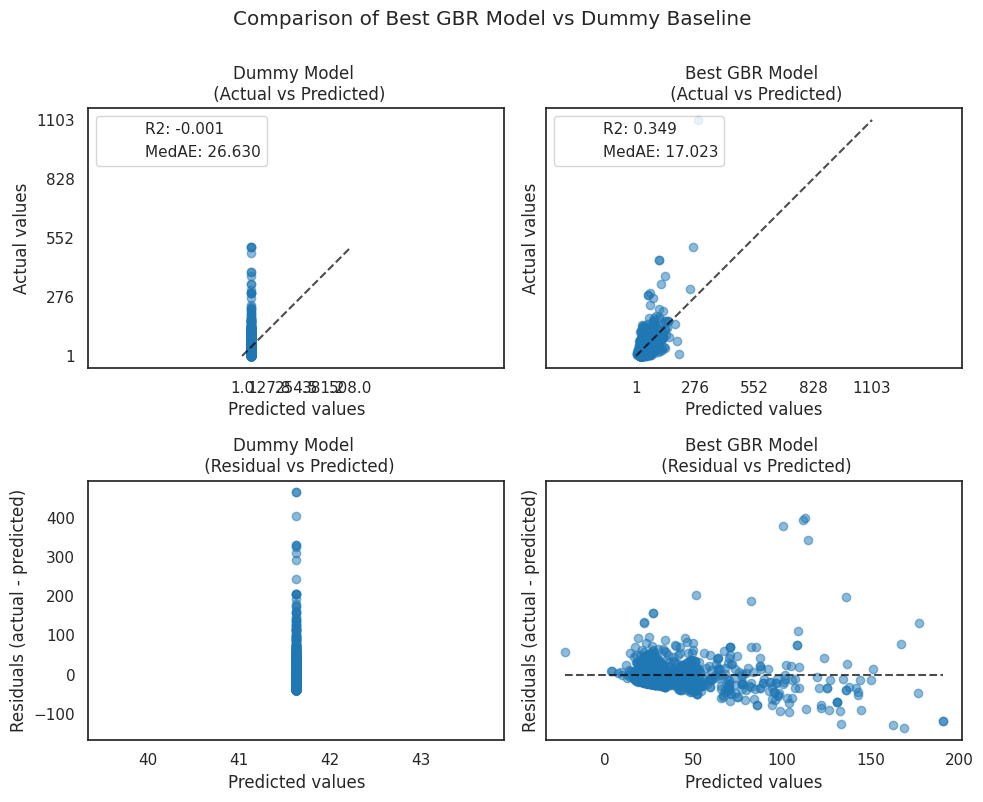

In [85]:
# Define the Dummy Model (Baseline)
dummy_regr = DummyRegressor(strategy="mean")
baseline_model = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('regressor_pipeline', dummy_regr)
])

# Get the best GBR model from models dictionary
best_model = models['GBR + RFE']

# Fit models and make predictions
y_pred_dummy = baseline_model.fit(X_train_sample, y_train_sample).predict(X_test_sample)
y_pred_best = best_model.fit(X_train_sample, y_train_sample).predict(X_test_sample)

# Create subplots (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, sharey="row", figsize=(10, 8))
(ax0, ax1) = axes  # Unpack into two rows

# Plot Actual vs Predicted values
PredictionErrorDisplay.from_predictions(
    y_test_sample, y_pred_dummy, kind="actual_vs_predicted",
    ax=ax0[0], scatter_kwargs={"alpha": 0.5, "color": "tab:blue"}
)
PredictionErrorDisplay.from_predictions(
    y_test_sample, y_pred_best, kind="actual_vs_predicted",
    ax=ax0[1], scatter_kwargs={"alpha": 0.5, "color": "tab:blue"}
)

# Add scores to legend
for ax, y_pred, model_name in zip([ax0[0], ax0[1]], [y_pred_dummy, y_pred_best], ["Dummy Model", "Best GBR Model"]):
    for name, score in compute_score(y_test_sample, y_pred).items():
        ax.plot([], [], " ", label=f"{name}: {score}")
    ax.legend(loc="upper left")
    ax.set_title(f"{model_name} \n (Actual vs Predicted)")

# Plot Residuals vs Predicted values
PredictionErrorDisplay.from_predictions(
    y_test_sample, y_pred_dummy, kind="residual_vs_predicted",
    ax=ax1[0], scatter_kwargs={"alpha": 0.5, "color": "tab:blue"}
)
PredictionErrorDisplay.from_predictions(
    y_test_sample, y_pred_best, kind="residual_vs_predicted",
    ax=ax1[1], scatter_kwargs={"alpha": 0.5, "color": "tab:blue"}
)

ax1[0].set_title("Dummy Model \n (Residual vs Predicted)")
ax1[1].set_title("Best GBR Model \n (Residual vs Predicted)")

# Set overall title
fig.suptitle("Comparison of Best GBR Model vs Dummy Baseline", y=1.0)
plt.tight_layout()
plt.show()


In [105]:
best_model.named_steps["rfe"].get_feature_names_out()

array(['numeric_features__imputation__first_retailer_asking_price',
       'numeric_features__imputation__last_retailer_asking_price',
       'numeric_features__imputation__adjusted_retail_amount_gbp'],
      dtype=object)

## Final Numerical trick (Capping outliers in the target)

A second look at the time to sell prices

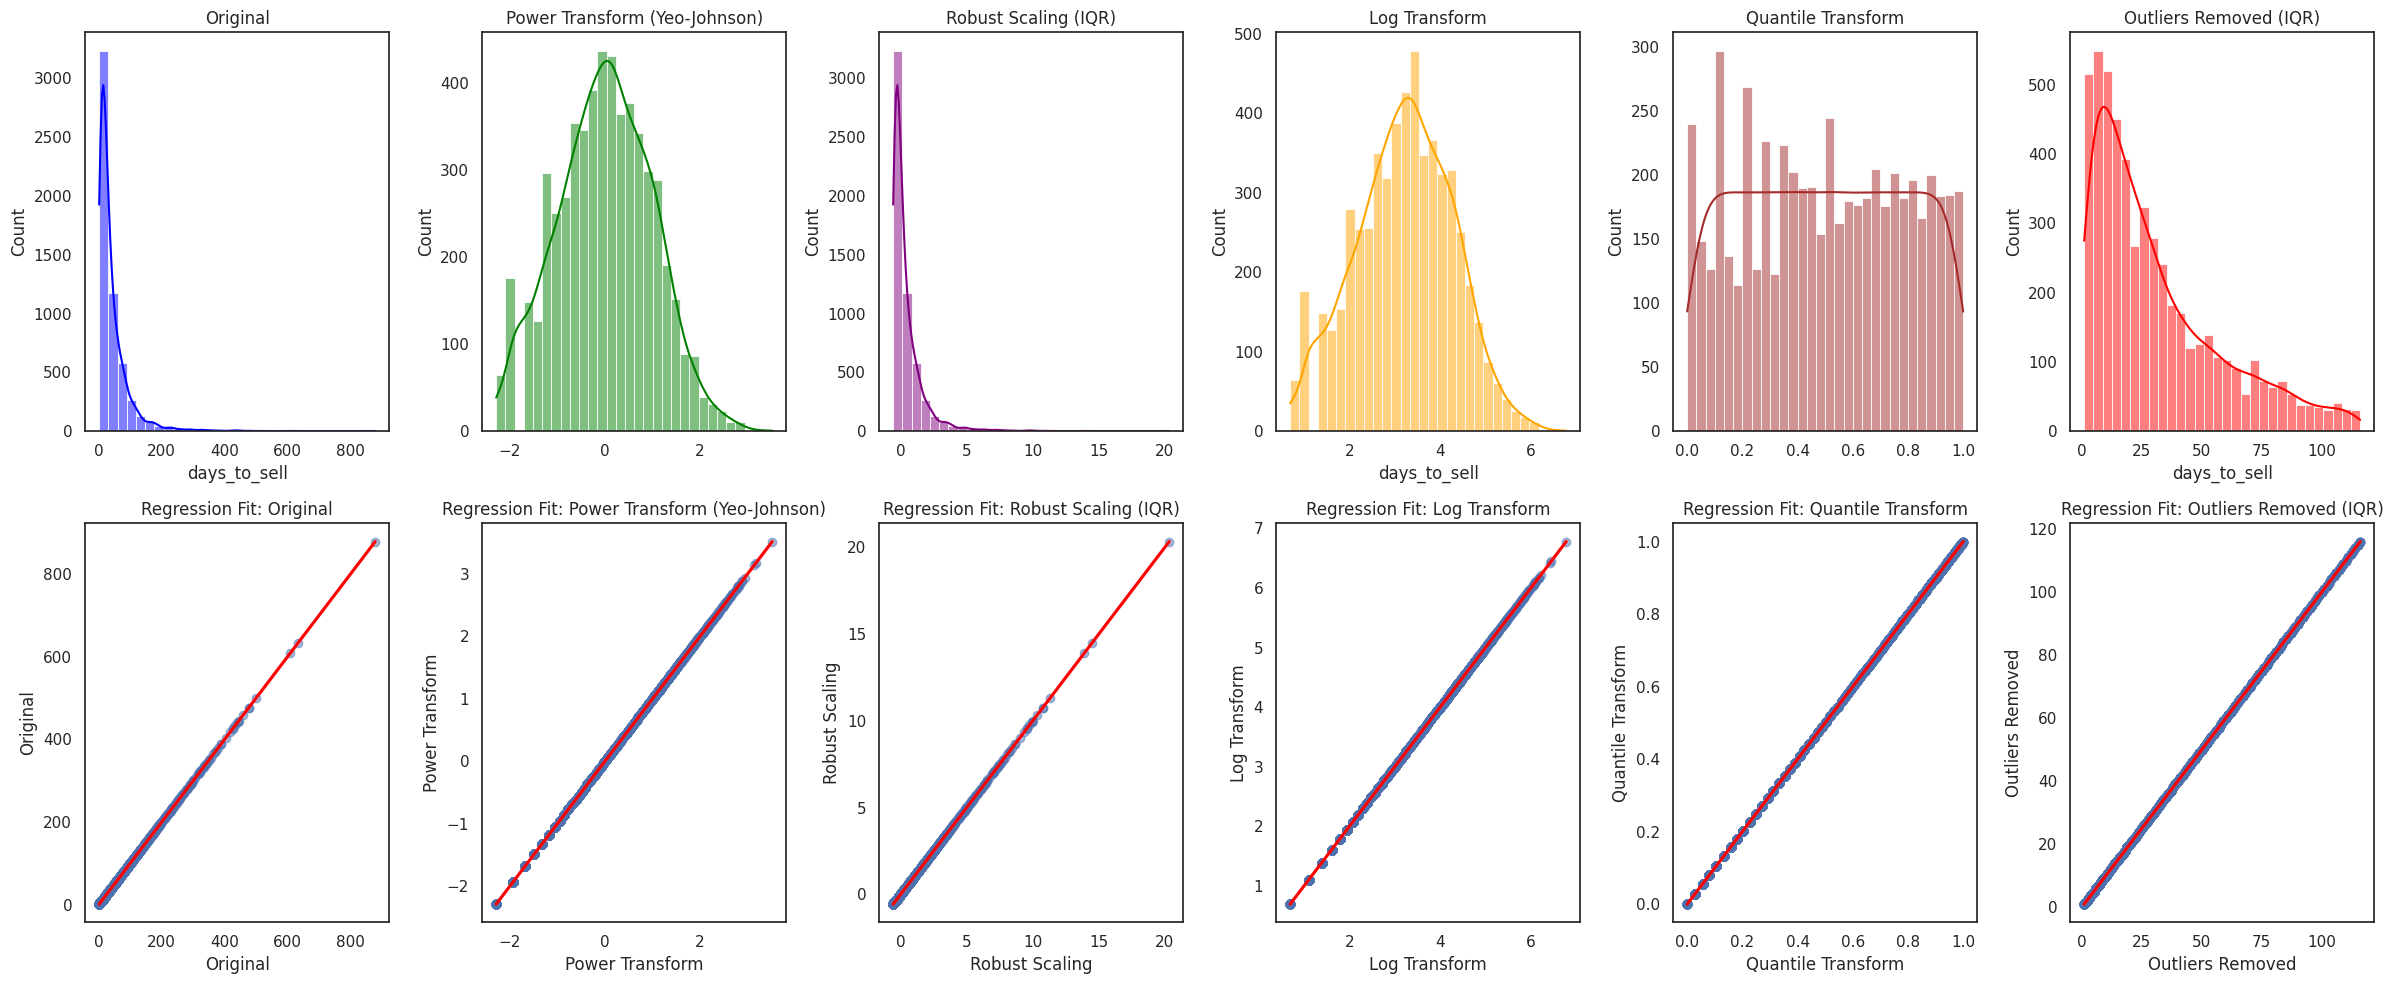

In [151]:
from sklearn.preprocessing import PowerTransformer, RobustScaler, QuantileTransformer
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure y_train_sample is a Pandas Series
y_train_original = y_train_sample.copy()

# Power Transformation (Yeo-Johnson)
power_transformer = PowerTransformer(method="yeo-johnson")
y_train_power = power_transformer.fit_transform(y_train_sample.values.reshape(-1, 1)).flatten()

# Robust Scaling (Median & IQR-based)
robust_scaler = RobustScaler()
y_train_robust = robust_scaler.fit_transform(y_train_sample.values.reshape(-1, 1)).flatten()

# Log Transformation (handling zero or negative values)
y_train_log = np.log1p(y_train_sample)  # log(1 + x) to handle zero or negative values

# Quantile Transformation (Uniform distribution)
quantile_transformer = QuantileTransformer(output_distribution='uniform')
y_train_quantile = quantile_transformer.fit_transform(y_train_sample.values.reshape(-1, 1)).flatten()

# Outlier Removal using IQR
Q1 = np.percentile(y_train_sample, 25)
Q3 = np.percentile(y_train_sample, 75)
IQR = Q3 - Q1
lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

# Remove outliers
y_train_outliers_removed = y_train_sample[(y_train_sample >= lower_bound) & (y_train_sample <= upper_bound)]

# Create a DataFrame for Regression Plots
df = pd.DataFrame({
    "Original": y_train_original,
    "Power Transform": y_train_power,
    "Robust Scaling": y_train_robust,
    "Log Transform": y_train_log,
    "Quantile Transform": y_train_quantile
})

# Only include non-outliers for the Outlier Removal model
df_outliers_removed = pd.DataFrame({"Outliers Removed": y_train_outliers_removed})

# Create Subplots: Histograms (Top Row) & Regression Plots (Bottom Row)
fig, axes = plt.subplots(2, 6, figsize=(24, 10), sharex=False)

# Titles for each transformation
titles = ["Original", "Power Transform (Yeo-Johnson)", "Robust Scaling (IQR)", "Log Transform", "Quantile Transform", "Outliers Removed (IQR)"]
datasets = [y_train_original, y_train_power, y_train_robust, y_train_log, y_train_quantile, y_train_outliers_removed]

# Top Row: Histograms
for i, (data, title) in enumerate(zip(datasets, titles)):
    sns.histplot(data, bins=30, kde=True, ax=axes[0, i], color=["blue", "green", "purple", "orange", "brown", "red"][i])
    axes[0, i].set_title(title)

# Bottom Row: Regression Plots
for i, (col, title) in enumerate(zip(["Original", "Power Transform", "Robust Scaling", "Log Transform", "Quantile Transform", "Outliers Removed"], titles)):
    if col == "Outliers Removed":
        sns.regplot(x=df_outliers_removed[col], y=df_outliers_removed[col], ax=axes[1, i], scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
    else:
        sns.regplot(x=df[col], y=df[col], ax=axes[1, i], scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
    
    axes[1, i].set_title(f"Regression Fit: {title}")

# Adjust layout
plt.tight_layout()
plt.show()


In [117]:
# Function to cap target outliers using IQR method
def cap_target_outliers(y: pd.Series) -> pd.Series:
    """Cap target outliers using IQR method."""
    Q1 = np.percentile(y, 25)
    Q3 = np.percentile(y, 75)
    IQR = Q3 - Q1
    lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return np.clip(y, lower_bound, upper_bound)

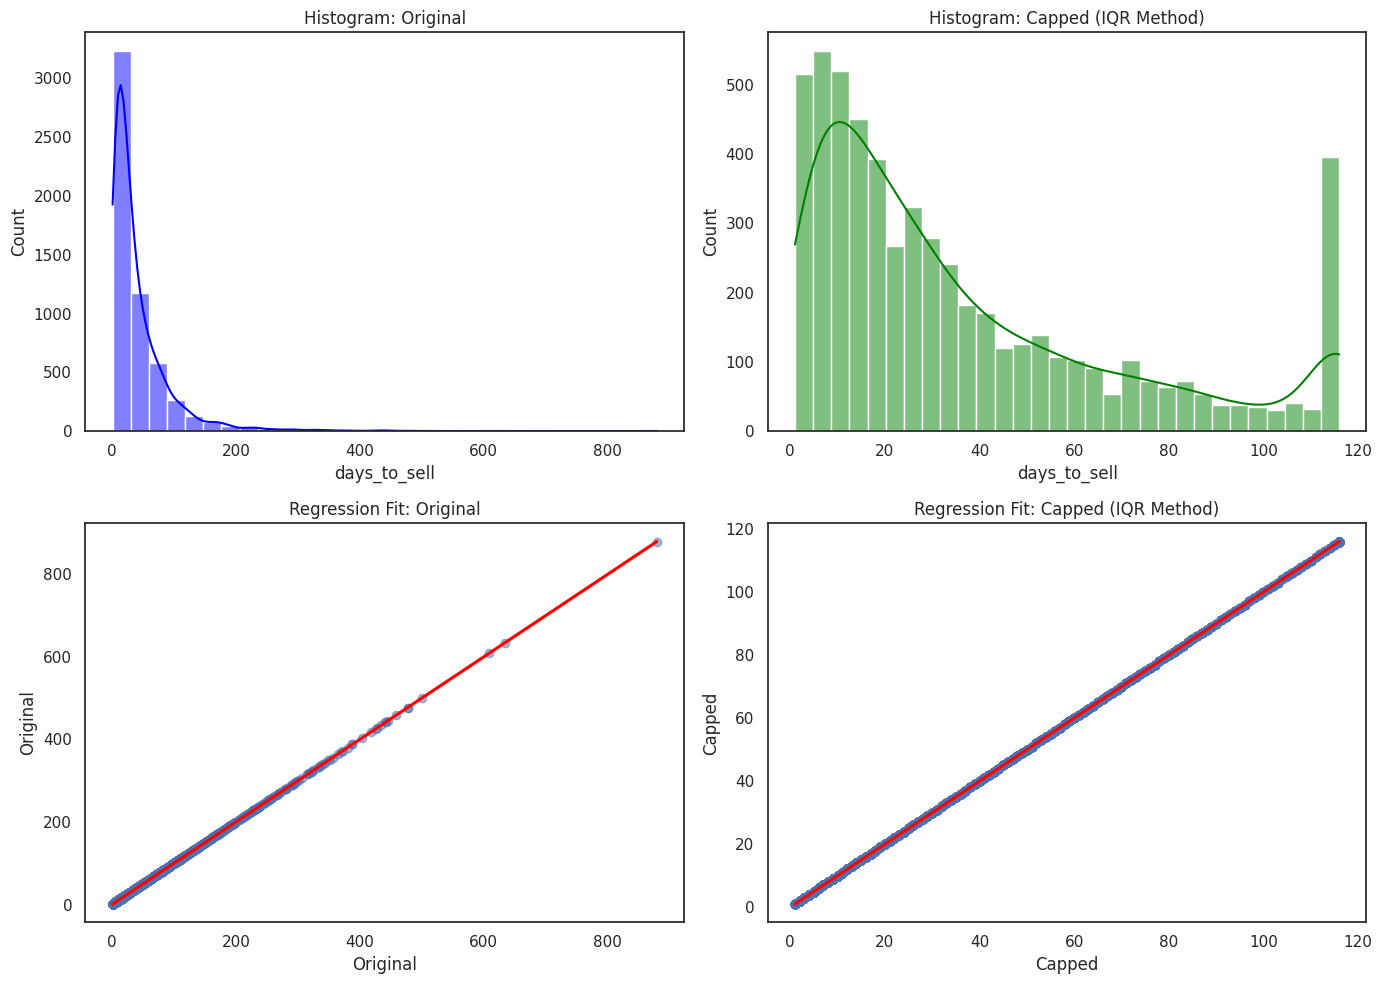

In [118]:
y_train_capped = cap_target_outliers(y_train_original)

# Create a DataFrame to store original and capped data for comparison
df = pd.DataFrame({
    'Original': y_train_sample,
    'Capped': y_train_capped
})

# Create subplots: Histograms (Top Row) & Regression Plots (Bottom Row)
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=False)

# Titles for each transformation
titles = ["Original", "Capped (IQR Method)"]
datasets = [y_train_sample, y_train_capped]

# Top Row: Histograms
for i, (data, title) in enumerate(zip(datasets, titles)):
    sns.histplot(data, bins=30, kde=True, ax=axes[0, i], color=["blue", "green"][i])
    axes[0, i].set_title(f"Histogram: {title}")

# Bottom Row: Regression Plots
for i, (col, title) in enumerate(zip(["Original", "Capped"], titles)):
    sns.regplot(x=df[col], y=df[col], ax=axes[1, i], scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
    axes[1, i].set_title(f"Regression Fit: {title}")

# Adjust layout for better visibility
plt.tight_layout()
plt.show()


In [119]:
len(y_train_sample), len(y_train_capped)

(5604, 5604)

In [125]:
exp_baseline_model = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('rfe', rfecv_best),
    ('cap_target_outliers', FunctionTransformer(cap_target_outliers, validate=False)),
    ('regressor_pipeline', dummy_regr)
])

exp_baseline_model

Pipeline(steps=[('data_preparation',
                 Pipeline(steps=[('drop_columns',
                                  FunctionTransformer(func=<function drop_features at 0x73cfc4d6ade0>)),
                                 ('replace_none',
                                  FunctionTransformer(func=<function replace_none_with_nan at 0x73cfc4d6ac00>)),
                                 ('convert_2numeric',
                                  FunctionTransformer(func=<function convert_columns_to_numeric at 0x73cfc4d6af20>))])),
                ('data_preprocessor',...
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x73cfd0082490>)])),
                ('rfe',
                 RFECV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                       estimator=RandomForestRegressor(random_state=42),
                       n_jobs=-1, scoring='r2')),
                ('cap_target_outliers',
                 FunctionTransformer(func=<function cap_target_outliers at 0x73d02f508ae0>)),
                ('regressor_pipeline', DummyRegressor())])

In [126]:
y_pred_basemodel = best_model.fit(X_train_sample, y_train_sample).predict(X_test_sample)
y_pred_exp_basemodel = exp_baseline_model.fit(X_train_sample, y_train_sample).predict(X_test_sample)

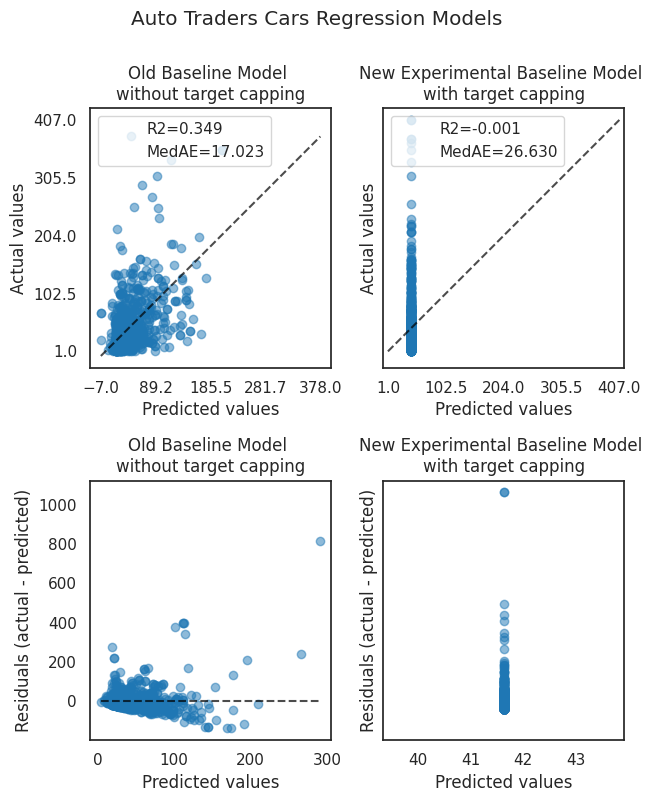

In [127]:
# Create subplots for the actual vs predicted and residuals vs predicted plots
f, (ax0, ax1) = plt.subplots(2, 2, sharey="row", figsize=(6.5, 8))

# Plot the actual vs predicted values for both models
PredictionErrorDisplay.from_predictions(
    y_test_sample,
    y_pred_basemodel,
    kind="actual_vs_predicted",
    ax=ax0[0],
    scatter_kwargs={"alpha": 0.5},
)
PredictionErrorDisplay.from_predictions(
    y_test_sample,
    y_pred_exp_basemodel,
    kind="actual_vs_predicted",
    ax=ax0[1],
    scatter_kwargs={"alpha": 0.5},
)

# Add the score in the legend of each axis
for ax, y_pred in zip([ax0[0], ax0[1]], [y_pred_basemodel, y_pred_exp_basemodel]):
    for name, score in compute_score(y_test_sample, y_pred).items():
        ax.plot([], [], " ", label=f"{name}={score}")
    ax.legend(loc="upper left")

ax0[0].set_title("Old Baseline Model \nwithout target capping")
ax0[1].set_title("New Experimental Baseline Model \nwith target capping")

# Plot the residuals vs the predicted values for both models
PredictionErrorDisplay.from_predictions(
    y_test_sample,
    y_pred_basemodel,
    kind="residual_vs_predicted",
    ax=ax1[0],
    scatter_kwargs={"alpha": 0.5},
)
PredictionErrorDisplay.from_predictions(
    y_test_sample,
    y_pred_exp_basemodel,
    kind="residual_vs_predicted",
    ax=ax1[1],
    scatter_kwargs={"alpha": 0.5},
)

ax1[0].set_title("Old Baseline Model \nwithout target capping")
ax1[1].set_title("New Experimental Baseline Model \nwith target capping")

# Set the main title for the figure
f.suptitle("Auto Traders Cars Regression Models", y=1.0)
plt.tight_layout()
plt.show()


In [130]:
# Function to remove outliers from target using IQR method
def remove_target_outliers(y: pd.Series) -> pd.Series:
    """Remove target outliers using IQR method."""
    Q1 = np.percentile(y, 25)
    Q3 = np.percentile(y, 75)
    IQR = Q3 - Q1
    lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return y[(y >= lower_bound) & (y <= upper_bound)]

# Make a copy of the data
X_train_sample_copy = X_train_sample.copy()
y_train_sample_copy = y_train_sample.copy()

# Remove outliers from y_train_sample
y_train_filtered = remove_target_outliers(y_train_sample_copy)

# Index the corresponding data in X_train_sample by filtering with the same condition
X_train_filtered = X_train_sample_copy[y_train_sample_copy.index.isin(y_train_filtered.index)]

# Split the filtered data into train and test sets
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_train_filtered, y_train_filtered, test_size=0.2, random_state=42
)

In [ ]:
y_pred_basemodel = best_model.fit(X_train_final, y_train_final).predict(X_test_final)

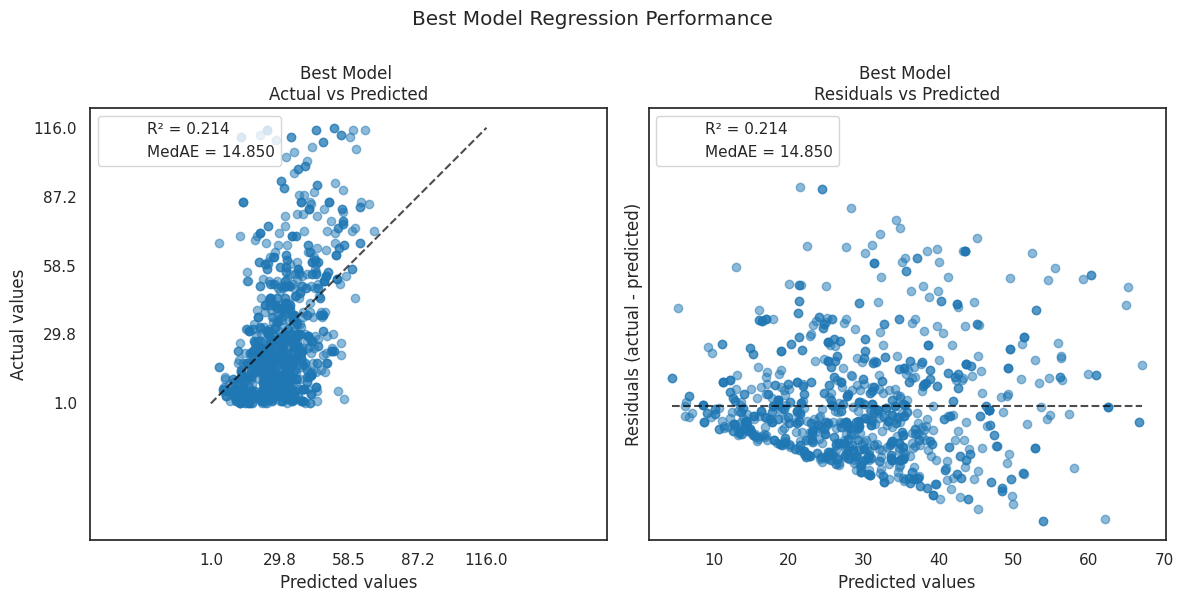

In [134]:
# Compute R² and MedAE scores
r2 = r2_score(y_test_final, y_pred_basemodel)
medae = median_absolute_error(y_test_final, y_pred_basemodel)

# Create a subplot for the actual vs predicted and residuals vs predicted plot for the best_model
f, (ax0, ax1) = plt.subplots(1, 2, sharey="row", figsize=(12, 6))

# Plot the actual vs predicted values for the best_model
PredictionErrorDisplay.from_predictions(
    y_test_final,
    y_pred_basemodel,
    kind="actual_vs_predicted",
    ax=ax0,
    scatter_kwargs={"alpha": 0.5},
)

# Plot the residuals vs predicted values for the best_model
PredictionErrorDisplay.from_predictions(
    y_test_final,
    y_pred_basemodel,
    kind="residual_vs_predicted",
    ax=ax1,
    scatter_kwargs={"alpha": 0.5},
)

# Add the R² and MedAE scores to the legend
for ax in [ax0, ax1]:
    ax.plot([], [], " ", label=f"R² = {r2:.3f}")
    ax.plot([], [], " ", label=f"MedAE = {medae:.3f}")
    ax.legend(loc="upper left")

# Set titles for the subplots
ax0.set_title("Best Model \nActual vs Predicted")
ax1.set_title("Best Model \nResiduals vs Predicted")

# Set the main title for the figure
f.suptitle("Best Model Regression Performance", y=1.0)

# Adjust layout for better visibility
plt.tight_layout()
plt.show()


In [30]:
def plot_regression_performance(y_test, y_pred, plot_title="Best Model Regression Performance"):
    # Compute R² and MedAE scores
    r2 = r2_score(y_test, y_pred)
    medae = median_absolute_error(y_test, y_pred)

    # Create subplots
    f, (ax0, ax1) = plt.subplots(1, 2, sharey="row", figsize=(12, 6))

    # Actual vs predicted plot
    PredictionErrorDisplay.from_predictions(
        y_test, y_pred, kind="actual_vs_predicted", ax=ax0, scatter_kwargs={"alpha": 0.5}
    )

    # Residuals vs predicted plot
    PredictionErrorDisplay.from_predictions(
        y_test, y_pred, kind="residual_vs_predicted", ax=ax1, scatter_kwargs={"alpha": 0.5}
    )

    # Add scores to legend
    for ax in [ax0, ax1]:
        ax.plot([], [], " ", label=f"R² = {r2:.3f}")
        ax.plot([], [], " ", label=f"MedAE = {medae:.3f}")
        ax.legend(loc="upper left")

    # Titles and figure layout
    ax0.set_title("Best Model \nActual vs Predicted")
    ax1.set_title("Best Model \nResiduals vs Predicted")
    f.suptitle(plot_title, y=1.0)

    # Show plot
    plt.tight_layout()
    plt.show()


## Experimenting Bayesian methods

In [186]:
#models
brr = BayesianRidge()
ard = ARDRegression()
#gbr

#transformers
quantile_transform = QuantileTransformer(n_quantiles=900, output_distribution="normal")
power_transformer = PowerTransformer()

quantile_target_trans = TransformedTargetRegressor(
    regressor=gbr,
    transformer=power_transformer,
)

model_quantile_pipeline = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('rfe', rfecv_best),
    ('regressor_pipeline', quantile_target_trans)
])

Power transform transform grb model

In [188]:
#model_quantile_pipeline.fit(X_train_sample, y_train_sample)
title_desc = 'power transform gbr model'
print(f'{title_desc} Train score {model_quantile_pipeline.score(X_train_sample, y_train_sample)}')
print(f'{title_desc} Test score {model_quantile_pipeline.score(X_test_sample, y_test_sample)}')

power transform gbr model Train score 0.3655183738277128
power transform gbr model Test score 0.25785864764633226


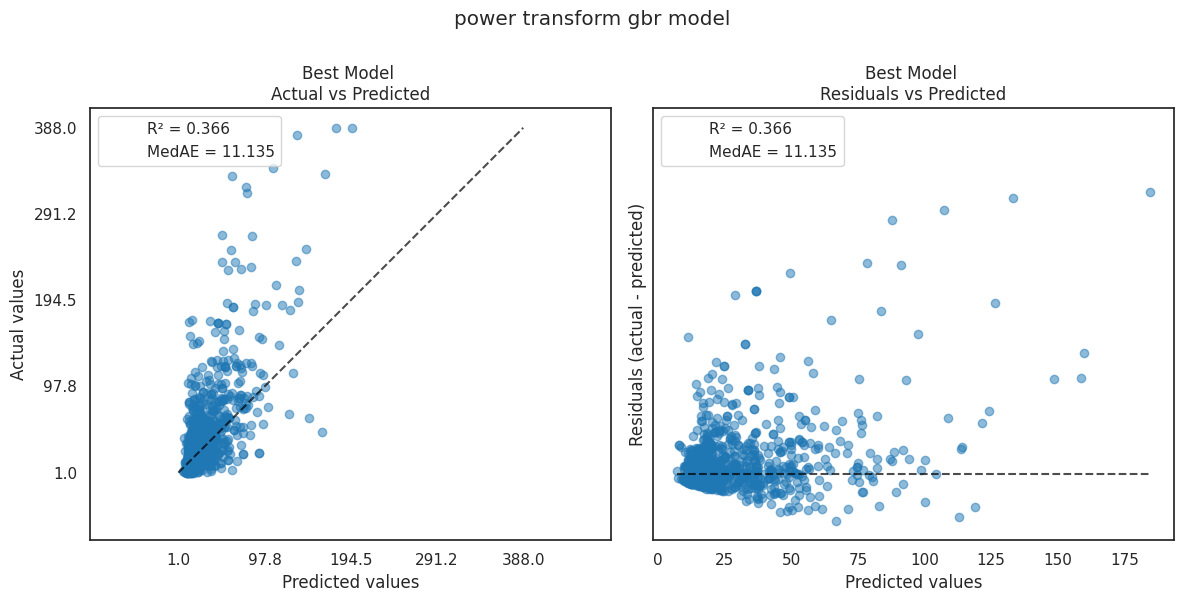

In [189]:
y_pred_train = model_quantile_pipeline.predict(X_train_sample)
plot_regression_performance(y_train_sample, y_pred_train, plot_title=title_desc)

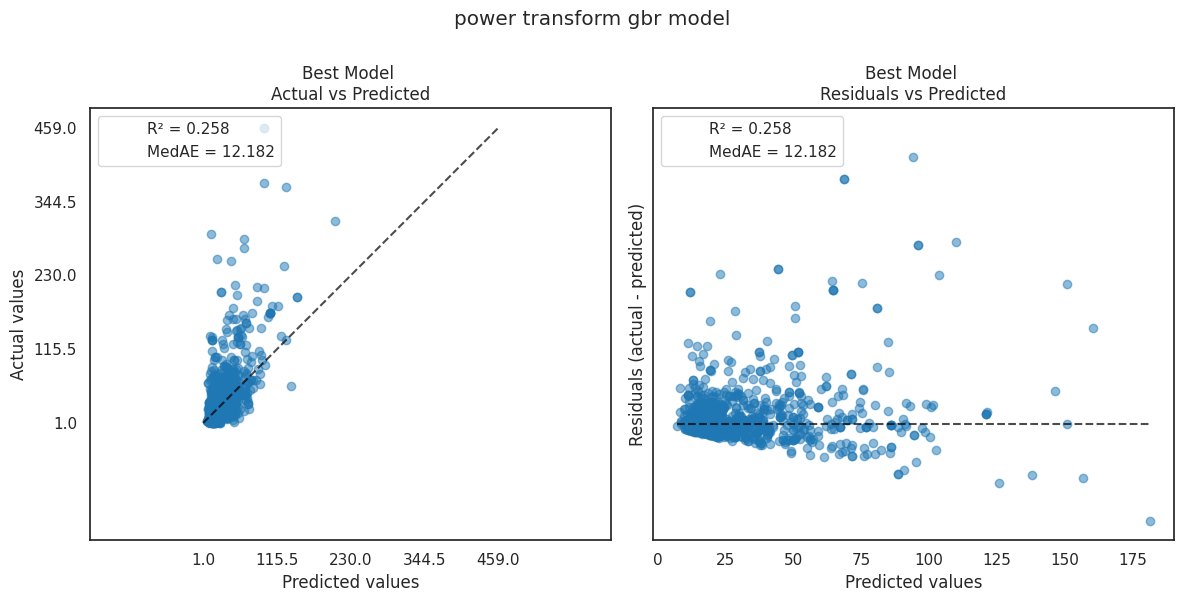

In [190]:
y_pred_test = model_quantile_pipeline.predict(X_test_sample)
plot_regression_performance(y_test_sample, y_pred_test, plot_title=title_desc)

default quantile transform ard model

In [183]:
model_quantile_pipeline.fit(X_train_sample, y_train_sample)
title_desc = 'default quantile transform gbr model'
print(f'{title_desc} Train score {model_quantile_pipeline.score(X_train_sample, y_train_sample)}')
print(f'{title_desc} Test score {model_quantile_pipeline.score(X_test_sample, y_test_sample)}')

default quantile transform gbr model Train score 0.36885867565334685
default quantile transform gbr model Test score 0.26328997544043886


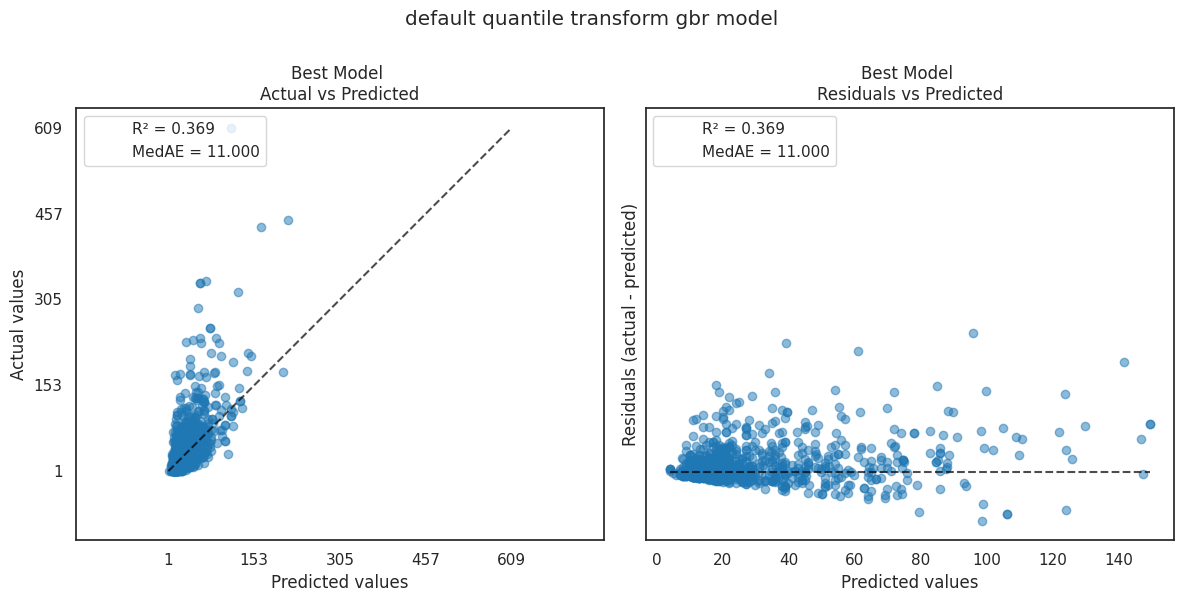

In [184]:
y_pred_train = model_quantile_pipeline.predict(X_train_sample)
plot_regression_performance(y_train_sample, y_pred_train, plot_title=title_desc)

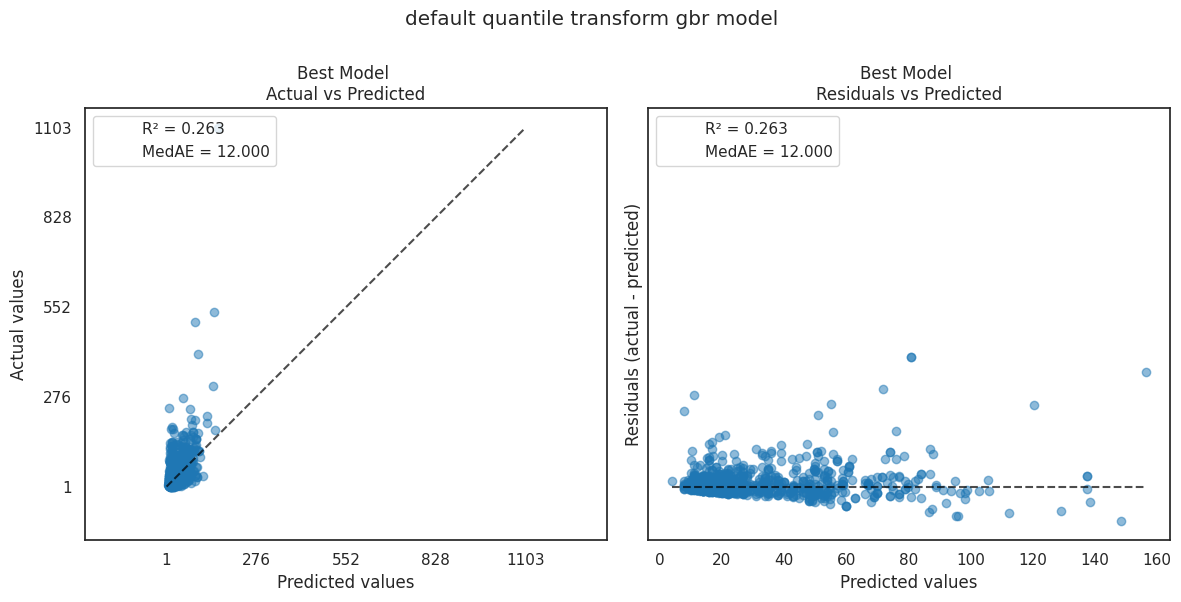

In [185]:
y_pred_test = model_quantile_pipeline.predict(X_test_sample)
plot_regression_performance(y_test_sample, y_pred_test, plot_title=title_desc)

900 quantile transform ard model

In [179]:
model_quantile_pipeline.fit(X_train_sample, y_train_sample)
title_desc = '900 quantile transform ard model'
print(f'{title_desc} Train score {model_quantile_pipeline.score(X_train_sample, y_train_sample)}')
print(f'{title_desc} Test score {model_quantile_pipeline.score(X_test_sample, y_test_sample)}')

900 quantile transform ard model Train score -0.08857070264176592
900 quantile transform ard model Test score -0.0704620976411583


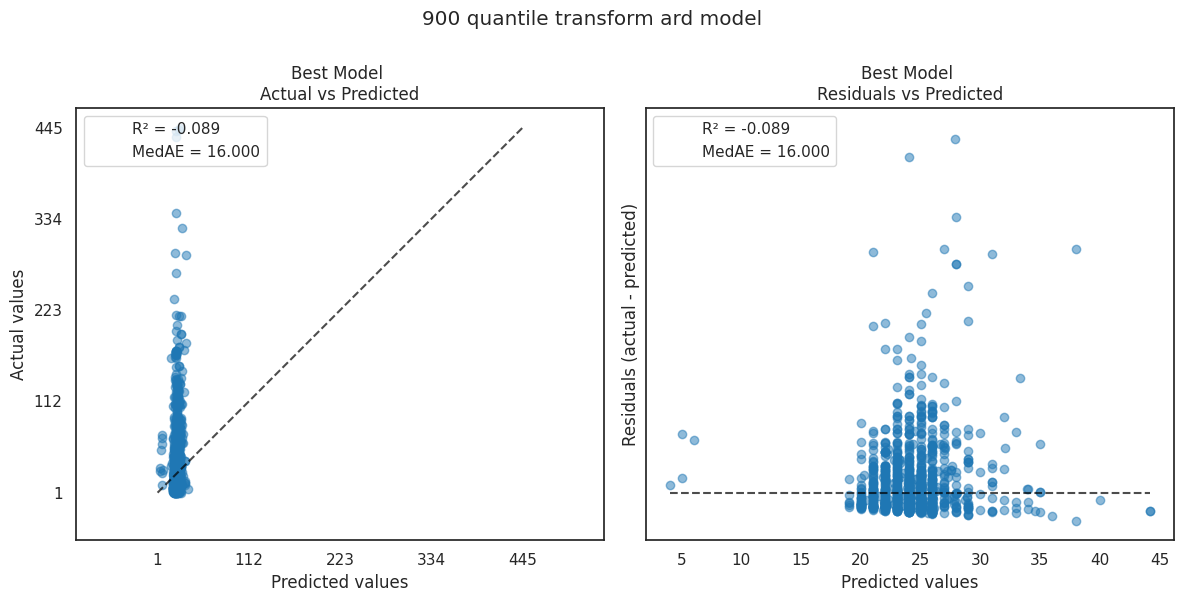

In [180]:
y_pred_train = model_quantile_pipeline.predict(X_train_sample)
plot_regression_performance(y_train_sample, y_pred_train, plot_title=title_desc)

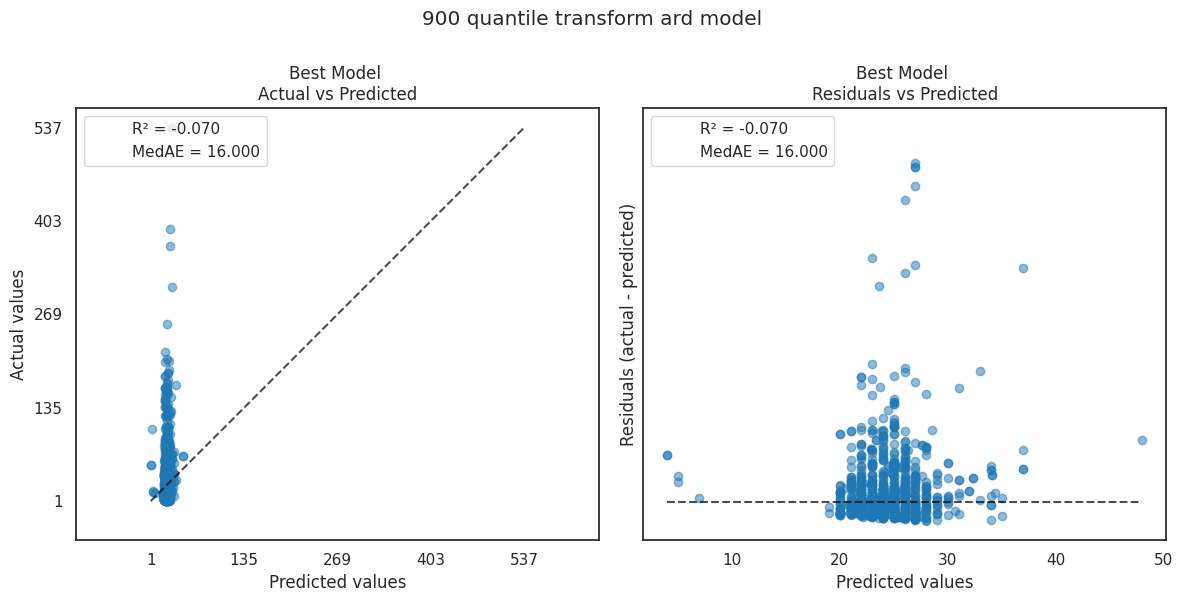

In [181]:
y_pred_test = model_quantile_pipeline.predict(X_test_sample)
plot_regression_performance(y_test_sample, y_pred_test, plot_title=title_desc)

900 quantile transform brr model

In [175]:
#model_quantile_pipeline.fit(X_train_sample, y_train_sample)
title_desc = '900 quantile transform brr model'
print(f'{title_desc} Train score {model_quantile_pipeline.score(X_train_sample, y_train_sample)}')
print(f'{title_desc} Test score {model_quantile_pipeline.score(X_test_sample, y_test_sample)}')

900 quantile transform brr model Train score -0.08881959976879705
900 quantile transform brr model Test score -0.07067883267208397


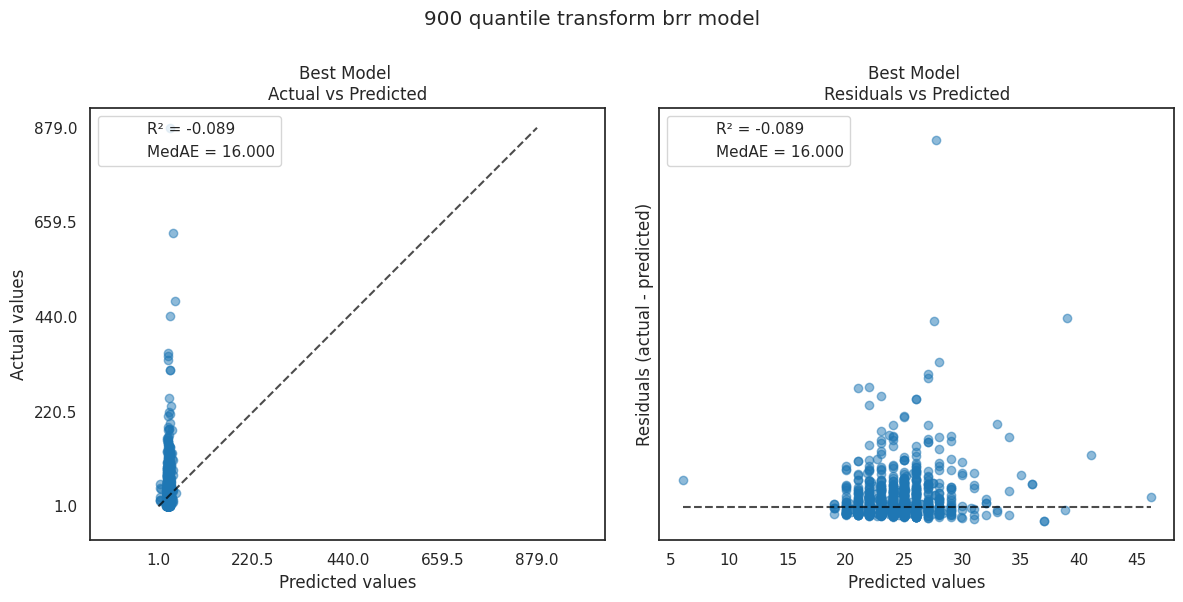

In [176]:
y_pred_train = model_quantile_pipeline.predict(X_train_sample)
plot_regression_performance(y_train_sample, y_pred_train, plot_title=title_desc)

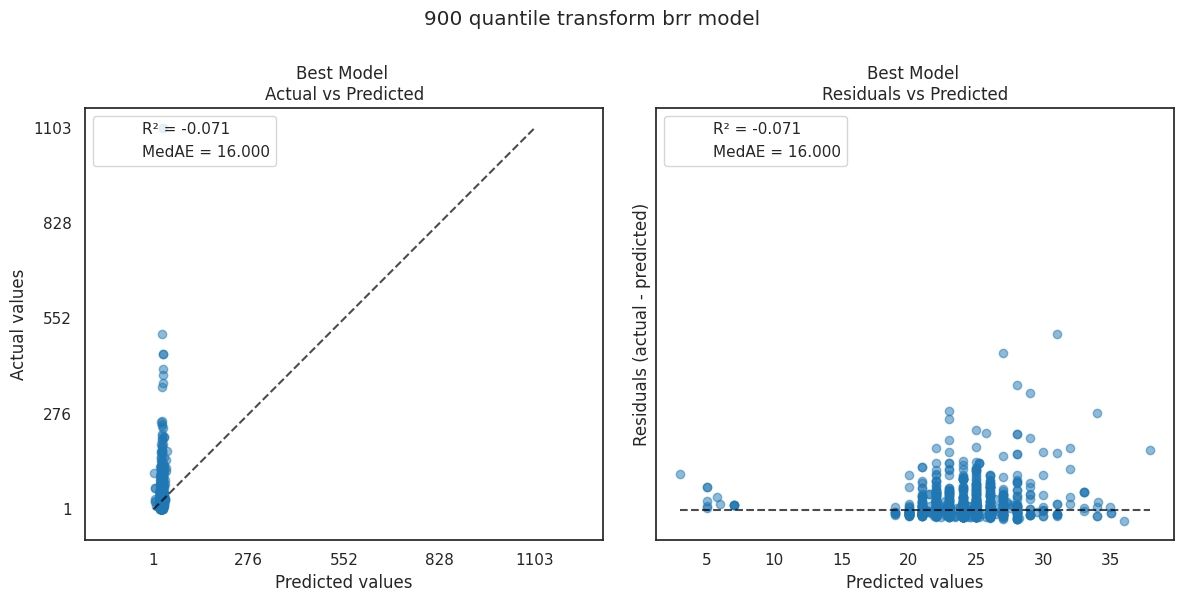

In [177]:
y_pred_test = model_quantile_pipeline.predict(X_test_sample)
plot_regression_performance(y_test_sample, y_pred_test, plot_title=title_desc)

900 quantile transform gbr model

In [166]:
#model_quantile_pipeline.fit(X_train_sample, y_train_sample)
title_desc = '900 quantile transform gbr model'
print(f'{title_desc} Train score {model_quantile_pipeline.score(X_train_sample, y_train_sample)}')
print(f'{title_desc} Test score {model_quantile_pipeline.score(X_test_sample, y_test_sample)}')

900 quantile transform gbr model Train score 0.3708994272217012
900 quantile transform gbr model Test score 0.272488145816544


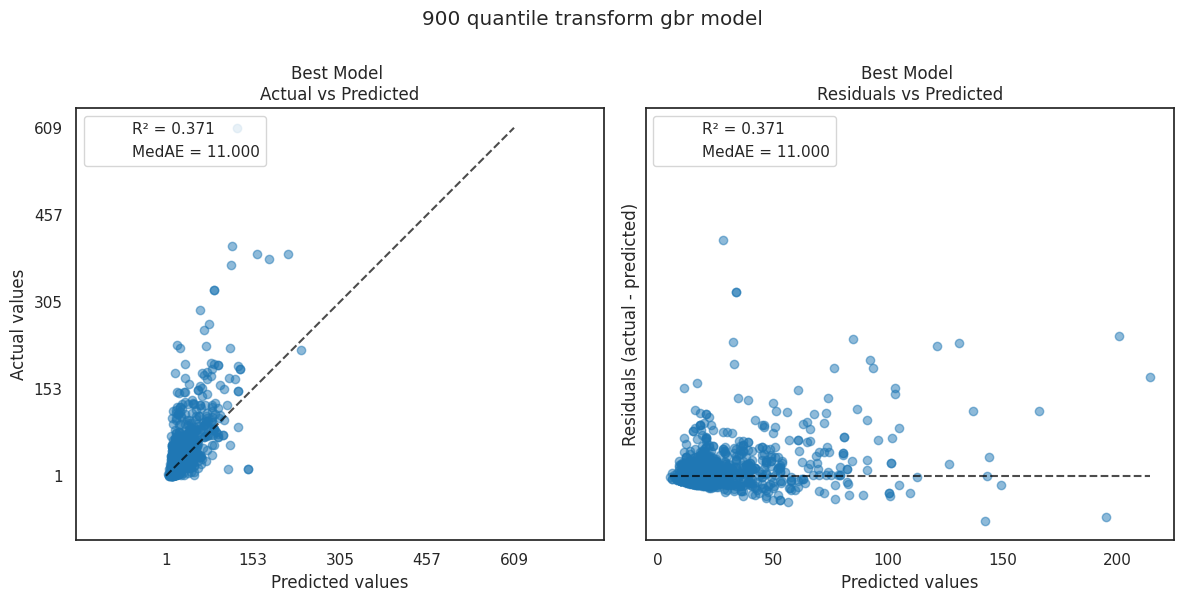

In [169]:
y_pred_train = model_quantile_pipeline.predict(X_train_sample)
plot_regression_performance(y_train_sample, y_pred_train, plot_title=title_desc)

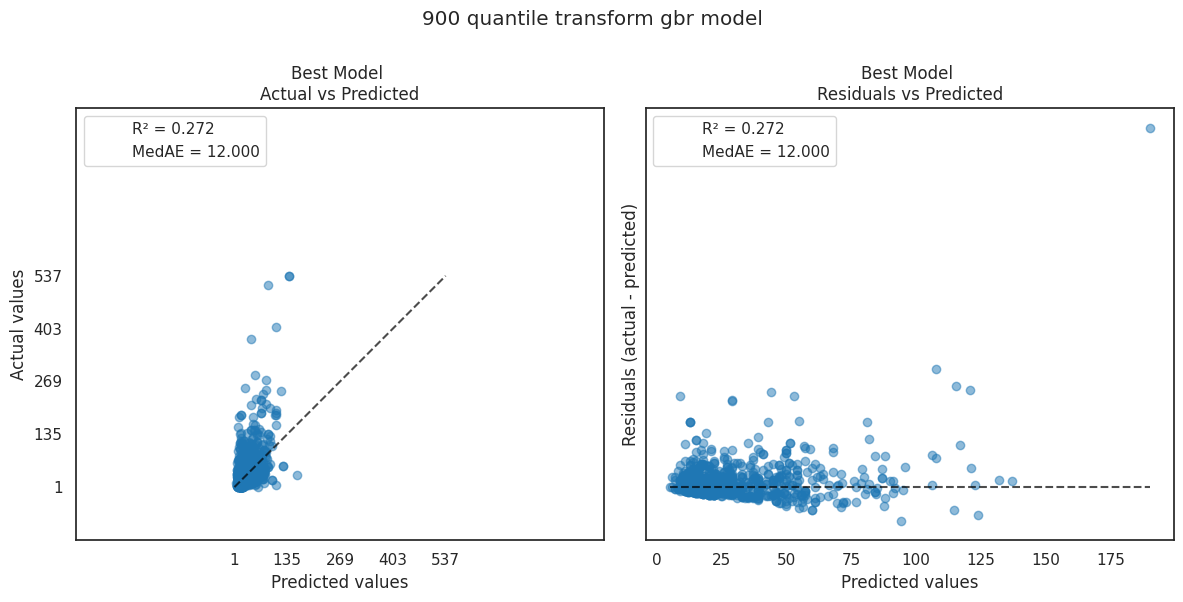

In [171]:
y_pred_test = model_quantile_pipeline.predict(X_test_sample)
plot_regression_performance(y_test_sample, y_pred_test, plot_title=title_desc)

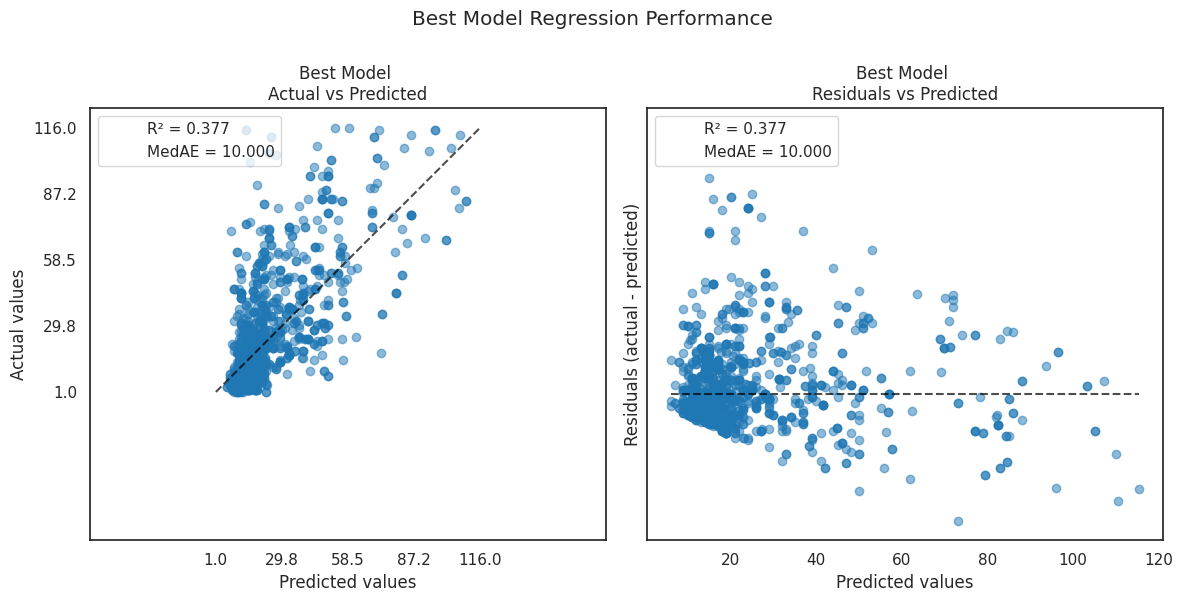

In [157]:
# Outlier in target removed with target quantile transform
plot_regression_performance(y_test_final, y_pred_basemodel)

In [158]:
from sklearn.linear_model import ARDRegression, BayesianRidge, LinearRegression

In [ ]:

quantile_transform = QuantileTransformer(output_distribution='normal')
power_transformer = PowerTransformer()

model_target_trans = TransformedTargetRegressor(
    regressor=gbr,
    transformer=QuantileTransformer(n_quantiles=900, output_distribution="normal"),
)

target_trans_pipeline = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('rfe', rfecv_best),
    ('regressor_pipeline', model_target_trans)
])

target_trans_pipeline.fit(X_train_sample, y_train_sample)
print(f'Train score {target_trans_pipeline.score(X_train_sample, y_train_sample)}')
print(f'Test score {target_trans_pipeline.score(X_test_sample, y_test_sample)}')

## Categorical Feature Exploration

In [247]:
cat_df = model_quantile_pipeline[:1].set_output(
    transform='pandas').fit_transform(
    X_train_sample).select_dtypes(
    include=["object", "bool"])

cat_df.columns

Index(['can_home_deliver', 'segment', 'make', 'model', 'generation',
       'derivative', 'body_type', 'fuel_type', 'transmission_type',
       'drivetrain', 'colour', 'attention_grabber', 'manufacturer_approved',
       'price_indicator_rating', 'first_image_label', 'postcode_area'],
      dtype='object')

In [212]:
cat_df.head(2)

,can_home_deliver,segment,make,model,generation,derivative,body_type,fuel_type,transmission_type,drivetrain,colour,attention_grabber,manufacturer_approved,price_indicator_rating,first_image_label,postcode_area
46997,False,Independent,Ford,Fusion,Hatchback (2005 - 2012),1.4 Zetec 5dr,Hatchback,Petrol,Manual,Front Wheel Drive,Silver,NATIONWIDE DELIVERY AVAILABLE,False,GREAT,FRONT_LEFT,HG
12633,False,Independent,Skoda,Octavia,Hatchback (2017 - 2020),2.0 TSI vRS Euro 6 (s/s) 5dr,Hatchback,Petrol,Manual,Front Wheel Drive,Grey,CLICK&COLLECT/HOME DELIVERY,False,GOOD,FRONT_RIGHT,DE


In [ ]:
['generation', 'derivative', 'attention_grabber']

In [213]:
clean_columns = ['can_home_deliver', 'segment', 'make', 'model', 
        'body_type', 'fuel_type', 'transmission_type',
       'drivetrain', 'colour', 'manufacturer_approved',
       'price_indicator_rating', 'first_image_label', 'postcode_area']

In [232]:

# Initialize TfidfVectorizer and CountVectorizer()
# text_vectorizer1 = CountVectorizer()
# text_vectorizer2 = TfidfVectorizer()
# TEXT_COLUMNS = ['attention_grabber', 'make', 'model']

# def apply_text_vectorizer(df: pd.DataFrame) -> hstack:
#     """Applies CountVectorizer to multiple text columns and returns a sparse feature matrix."""
#     transformed_cols = [text_vectorizer1.fit_transform(df[col]) for col in TEXT_COLUMNS]
#     return hstack(transformed_cols) 

DEFAULT_HOTENCODE_FEATURES = ['can_home_deliver', 'transmission_type', 'manufacturer_approved', 'segment', 'body_type', 'fuel_type', 'colour', 'first_image_label', 'drivetrain' ]

# Define ColumnTransformer
categorical_transformer = ColumnTransformer(
    [
        ('he_all', OneHotEncoder(sparse_output=False, min_frequency=0.05, handle_unknown="infrequent_if_exist"), DEFAULT_HOTENCODE_FEATURES),
        ('he_postcode', OneHotEncoder(sparse_output=False, min_frequency=0.01, handle_unknown="infrequent_if_exist"), ["postcode_area"]),
        ('oe_price_indicator', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), ["price_indicator_rating"]),
    ]
)

# Categorical pipeline
categorical_pipeline = Pipeline([
    ('emty_string_imputer', SimpleImputer(strategy='constant', fill_value="").set_output(transform='pandas')),  # Handle missing values for categorical
    ('categorical_encoder', categorical_transformer),
    ("selector", SelectPercentile(chi2, percentile=50))
])

In [222]:

categorical_preprocessors = [
    ("drop", "drop"),
    ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    (
        "one_hot",
        OneHotEncoder(handle_unknown="ignore", max_categories=20, sparse_output=False),
    ),
    ("target", TargetEncoder(target_type="continuous")),
]

In [223]:
categorical_preprocessors[-1]

('target', TargetEncoder(target_type='continuous'))

In [218]:
X_train_sample.shape, y_train_sample.shape

((5604, 42), (5604,))

In [263]:
preprocessor = TargetEncoder(target_type="continuous")
preprocessor2 = Pipeline([
        ('data_prep', data_preparation_pipeline), 
        ("encoder", TargetEncoder(target_type="continuous")),
        ('estimator', HistGradientBoostingRegressor(random_state=0, max_iter=max_iter)
)
])
preprocessor2.fit(X_train_sample, y_train_sample).score(X_train_sample, y_train_sample)

0.26061416666143566

In [266]:
preprocessor = Pipeline([
        ('data_prep', data_preparation_pipeline), 
        ("encoder", TargetEncoder(target_type="continuous")),
        ('estimator', HistGradientBoostingRegressor(random_state=0, max_iter=max_iter)
)
])
# Define KFold for CV
kf = KFold(n_splits=2, shuffle=True, random_state=42)

# Perform cross-validation
cv_results = cross_validate(
    preprocessor,
    X_train_filtered,
    y_train_filtered,
    scoring="neg_root_mean_squared_error",  # RMSE
    cv=kf,
    return_train_score=True,
    n_jobs=-1  # Parallel computation
)

# Extract scores
rmse_test_scores = -cv_results["test_score"]
rmse_train_scores = -cv_results["train_score"]

# Print CV results
print(f"Test RMSE: {rmse_test_scores.mean():.4f} ± {rmse_test_scores.std():.4f}")
print(f"Train RMSE: {rmse_train_scores.mean():.4f} ± {rmse_train_scores.std():.4f}")


Test RMSE: 25.4304 ± 0.0805
Train RMSE: 22.7835 ± 0.6552


In [325]:
# Define KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
max_iter = 20
results = []

In [326]:
def evaluate_model_and_store(name, pipe):
    result = cross_validate(
        pipe,
        X_train_sample,
        y_train_sample,
        scoring=["r2", "neg_root_mean_squared_error"],  # Use both R² and RMSE
        cv=kf,
        return_train_score=True,
    )
    rmse_test_score = -result["test_neg_root_mean_squared_error"]
    rmse_train_score = -result["train_neg_root_mean_squared_error"]
    r2_test_score = result["test_r2"]
    r2_train_score = result["train_r2"]

    results.append({
        "preprocessor": name,
        "r2_test_mean": r2_test_score.mean(),
        "r2_test_std": r2_test_score.std(),
        "r2_train_mean": r2_train_score.mean(),
        "r2_train_std": r2_train_score.std(),
        "rmse_test_mean": rmse_test_score.mean(),
        "rmse_test_std": rmse_test_score.std(),
        "rmse_train_mean": rmse_train_score.mean(),
        "rmse_train_std": rmse_train_score.std(),
    })


# List of categorical preprocessing methods
categorical_pipelines = [
    ('ordinal', Pipeline([
        ('data_prep', data_preparation_pipeline), 
        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))])
    ),
    ('one_hot', Pipeline([
        ('data_prep', data_preparation_pipeline), 
        ("encoder", OneHotEncoder(handle_unknown="ignore", max_categories=20, sparse_output=False))])
    ),
    ('target', Pipeline([
        ('data_prep', data_preparation_pipeline), 
        ("encoder", TargetEncoder(target_type="continuous"))])
    )
]

# Iterate through preprocessing methods and evaluate
for name, categorical_preprocessor in categorical_pipelines:
    columns_preprocessor = ColumnTransformer([
        ('categorical_features', categorical_preprocessor, clean_columns)
    ])

    pipe = make_pipeline(
        columns_preprocessor,
        HistGradientBoostingRegressor(random_state=0, max_iter=max_iter)
    )

    evaluate_model_and_store(name, pipe)


In [327]:
results

[{'preprocessor': 'ordinal',
  'r2_test_mean': np.float64(0.03420350030586157),
  'r2_test_std': np.float64(0.013156412016352792),
  'r2_train_mean': np.float64(0.1845928559079883),
  'r2_train_std': np.float64(0.006527777028735451),
  'rmse_test_mean': np.float64(51.98839304273398),
  'rmse_test_std': np.float64(4.570720991971898),
  'rmse_train_mean': np.float64(47.95722417499237),
  'rmse_train_std': np.float64(1.01544366955356)},
 {'preprocessor': 'one_hot',
  'r2_test_mean': np.float64(0.03737859101762879),
  'r2_test_std': np.float64(0.022071335443599543),
  'r2_train_mean': np.float64(0.15259600449922156),
  'r2_train_std': np.float64(0.006618698480646669),
  'rmse_test_mean': np.float64(51.883759041550796),
  'rmse_test_std': np.float64(4.387045945163829),
  'rmse_train_mean': np.float64(48.88742223516944),
  'rmse_train_std': np.float64(0.9527785459327865)},
 {'preprocessor': 'target',
  'r2_test_mean': np.float64(0.04202457040991088),
  'r2_test_std': np.float64(0.01884380540

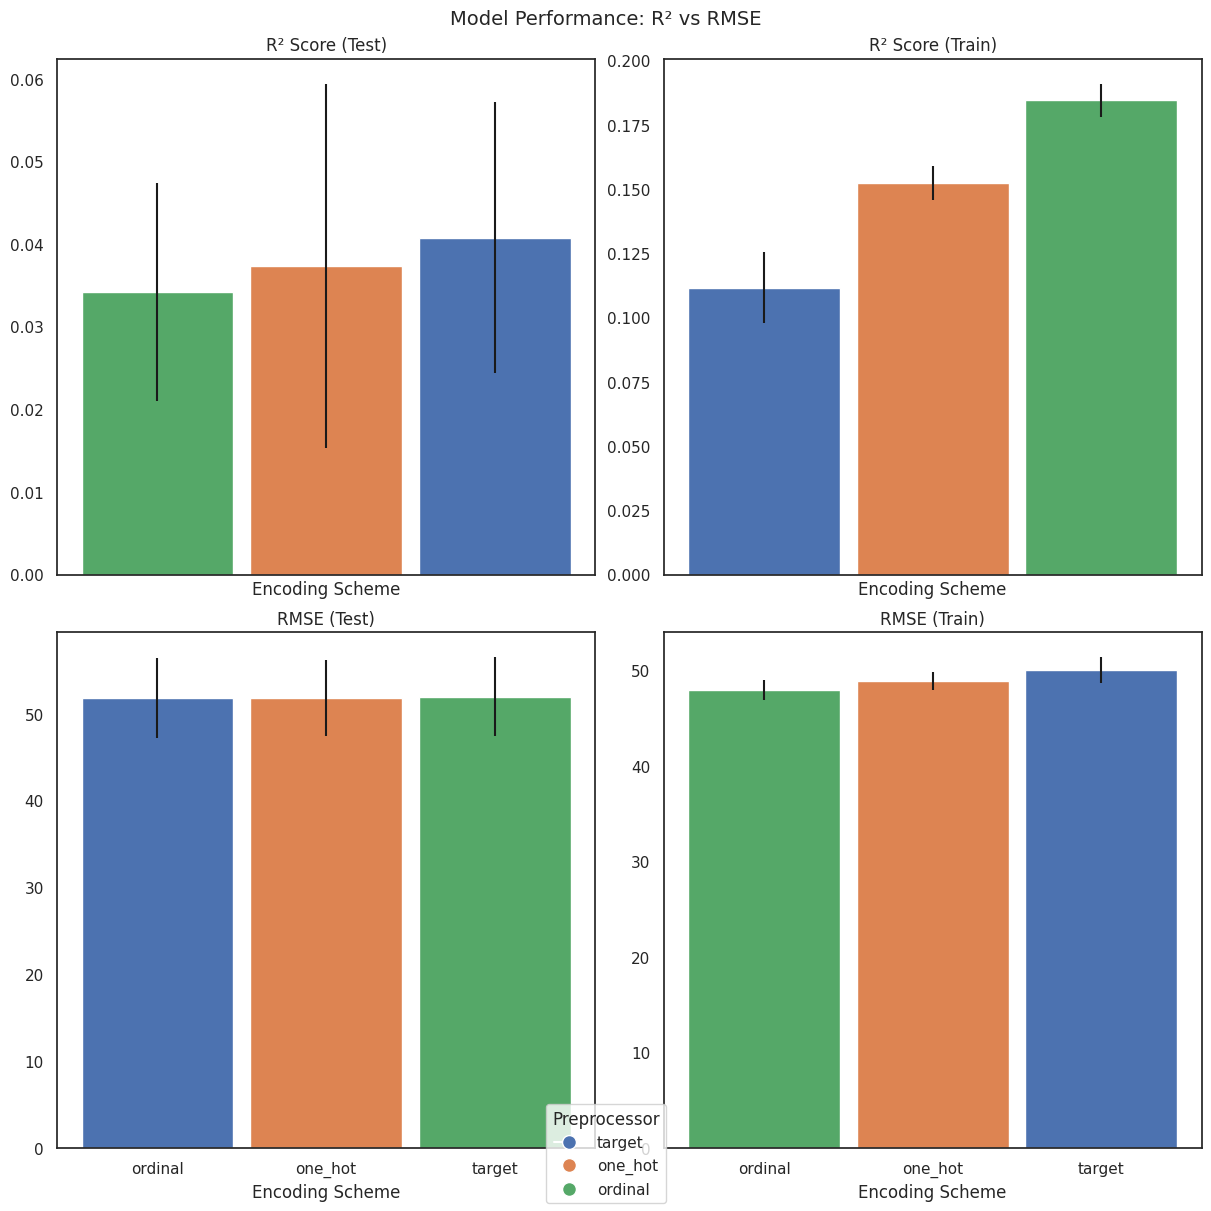

In [310]:

# Convert results list into DataFrame
results_df = pd.DataFrame(results).set_index("preprocessor")

# Sort by RMSE test mean for consistent order
results_df = results_df.sort_values("rmse_test_mean")

# Create subplots: Top (R²), Bottom (RMSE)
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharex=True, constrained_layout=True)
(ax1, ax2), (ax3, ax4) = axes  # Unpack axes

xticks = range(len(results_df))
name_to_color = dict(
    zip(results_df.index, ["C0", "C1", "C2"])
)

# Plot R² values (Top row)
for subset, ax in zip(["test", "train"], [ax1, ax2]):
    mean, std = f"r2_{subset}_mean", f"r2_{subset}_std"
    data = results_df[[mean, std]].sort_values(mean)
    bars = ax.bar(
        x=xticks,
        height=data[mean],
        yerr=data[std],
        width=0.9,
        color=[name_to_color[name] for name in data.index],
    )
    ax.set(
        title=f"R² Score ({subset.title()})",
        xlabel="Encoding Scheme",
        xticks=xticks,
        xticklabels=data.index,
    )

# Plot RMSE values (Bottom row)
for subset, ax in zip(["test", "train"], [ax3, ax4]):
    mean, std = f"rmse_{subset}_mean", f"rmse_{subset}_std"
    data = results_df[[mean, std]].sort_values(mean)
    bars = ax.bar(
        x=xticks,
        height=data[mean],
        yerr=data[std],
        width=0.9,
        color=[name_to_color[name] for name in data.index],
    )
    ax.set(
        title=f"RMSE ({subset.title()})",
        xlabel="Encoding Scheme",
        xticks=xticks,
        xticklabels=data.index,
    )

# Create custom legend for the colors
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) 
           for color in name_to_color.values()]
labels = list(name_to_color.keys())

# Add legend to the bottom plot (e.g., ax4)
fig.legend(handles, labels, title="Preprocessor", loc="lower center", ncol=len(name_to_color) // 2)

# Set a main title
fig.suptitle("Model Performance: R² vs RMSE", fontsize=14)

plt.show()


In [338]:
n_unique_categories = cat_df[cat_columns].nunique().sort_values(ascending=False)
n_unique_categories

attention_grabber         4133
derivative                3345
generation                 489
model                      485
postcode_area              115
make                        56
colour                      16
first_image_label           12
body_type                   11
fuel_type                    8
price_indicator_rating       6
segment                      4
drivetrain                   3
can_home_deliver             2
transmission_type            2
manufacturer_approved        2
dtype: int64

In [340]:
high_cardinality_features = n_unique_categories[n_unique_categories > 255].index
low_cardinality_features = n_unique_categories[n_unique_categories <= 255].index

In [341]:

mixed_encoded_preprocessor = ColumnTransformer(
    [
        (
            "high_cardinality",
            TargetEncoder(target_type="continuous"),
            high_cardinality_features,
        ),
        (
            "low_cardinality",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
            low_cardinality_features,
        ),
    ],
    verbose_feature_names_out=False,
)

# The output of the of the preprocessor must be set to pandas so the
# gradient boosting model can detect the low cardinality features.
mixed_encoded_preprocessor.set_output(transform="pandas")
mixed_pipe = make_pipeline(
    data_preparation_pipeline,
    mixed_encoded_preprocessor,
    HistGradientBoostingRegressor(
        random_state=0, max_iter=max_iter, categorical_features=low_cardinality_features
    ),
)
mixed_pipe

Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('drop_columns',
                                  FunctionTransformer(func=<function drop_features at 0x73cfc4d6ade0>)),
                                 ('replace_none',
                                  FunctionTransformer(func=<function replace_none_with_nan at 0x73cfc4d6ac00>)),
                                 ('convert_2numeric',
                                  FunctionTransformer(func=<function convert_columns_to_numeric at 0x73cfc4d6af20>))])),
                ('columntransformer',
                 ColumnTr...
                                   verbose_feature_names_out=False)),
                ('histgradientboostingregressor',
                 HistGradientBoostingRegressor(categorical_features=Index(['postcode_area', 'make', 'colour', 'first_image_label', 'body_type',
       'fuel_type', 'price_indicator_rating', 'segment', 'drivetrain',
       'can_home_deliver', 'transmission_type', 'manufacturer_approved'],
      dtype='object'),
                                               max_iter=20, random_state=0))])

In [328]:
evaluate_model_and_store("mixed_target", mixed_pipe)

In [329]:
results_df

,r2_test_mean,r2_test_std,r2_train_mean,r2_train_std,rmse_test_mean,rmse_test_std,rmse_train_mean,rmse_train_std
preprocessor,,,,,,,,
mixed_target,0.023683,0.015464,0.335407,0.021093,52.251234,4.382956,43.295463,1.319346


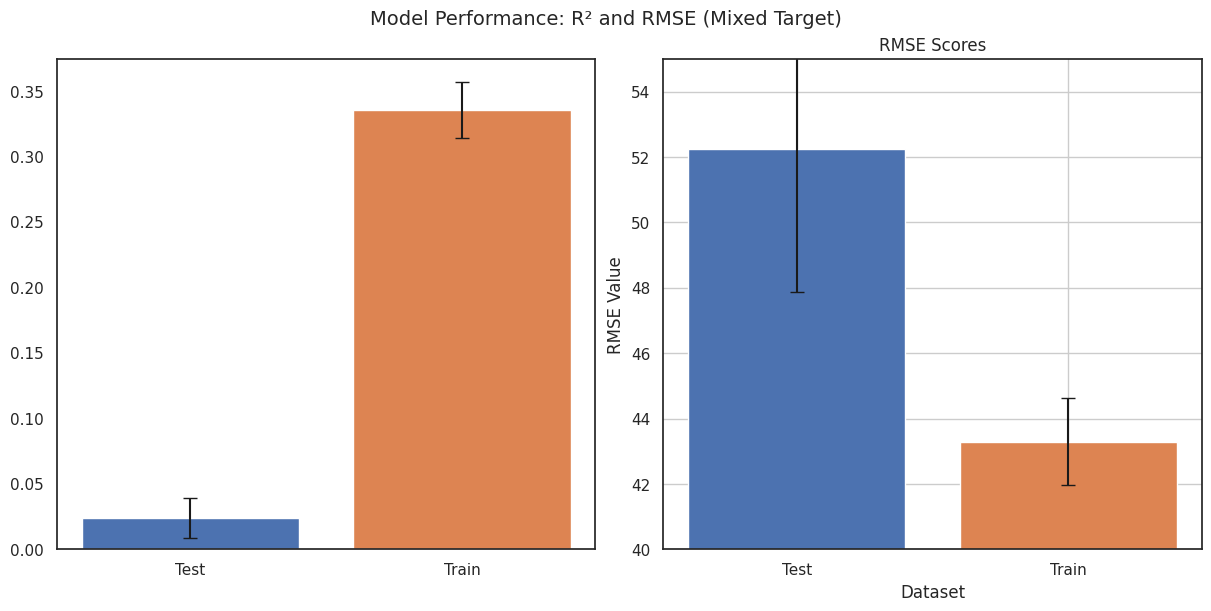

In [324]:
# Plot setup
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

# R² Plot
ax1.bar(
    ['Test', 'Train'],
    [results_df['r2_test_mean'].iloc[0], results_df['r2_train_mean'].iloc[0]],
    yerr=[results_df['r2_test_std'].iloc[0], results_df['r2_train_std'].iloc[0]],
    color=['C0', 'C1'],
    capsize=5
)

# RMSE Plot
ax2.bar(
    ['Test', 'Train'],
    [results_df['rmse_test_mean'].iloc[0], results_df['rmse_train_mean'].iloc[0]],
    yerr=[results_df['rmse_test_std'].iloc[0], results_df['rmse_train_std'].iloc[0]],
    color=['C0', 'C1'],
    capsize=5
)

ax2.set_title('RMSE Scores')
ax2.set_ylabel('RMSE Value')
ax2.set_ylim(40, 55)  # Set Y axis based on RMSE values
ax2.set_xlabel('Dataset')
ax2.grid(True)

# Add a main title to the figure
fig.suptitle('Model Performance: R² and RMSE (Mixed Target)', fontsize=14)

# Show the plot
plt.show()


In [ ]:
def plot_regression_performance(y_test, y_pred, plot_title="Best Model Regression Performance"):
    # Compute R² and MedAE scores
    r2 = r2_score(y_test, y_pred)
    medae = median_absolute_error(y_test, y_pred)

    # Create subplots
    f, (ax0, ax1) = plt.subplots(1, 2, sharey="row", figsize=(12, 6))

    # Actual vs predicted plot
    PredictionErrorDisplay.from_predictions(
        y_test, y_pred, kind="actual_vs_predicted", ax=ax0, scatter_kwargs={"alpha": 0.5}
    )

    # Residuals vs predicted plot
    PredictionErrorDisplay.from_predictions(
        y_test, y_pred, kind="residual_vs_predicted", ax=ax1, scatter_kwargs={"alpha": 0.5}
    )

    # Add scores to legend
    for ax in [ax0, ax1]:
        ax.plot([], [], " ", label=f"R² = {r2:.3f}")
        ax.plot([], [], " ", label=f"MedAE = {medae:.3f}")
        ax.legend(loc="upper left")

    # Titles and figure layout
    ax0.set_title("Best Model \nActual vs Predicted")
    ax1.set_title("Best Model \nResiduals vs Predicted")
    f.suptitle(plot_title, y=1.0)

    # Show plot
    plt.tight_layout()
    plt.show()


## Combined feature pipeline

In [12]:
# Data preprocessing pipeline
data_preparation_pipeline = Pipeline([
    ('drop_columns', FunctionTransformer(drop_features)), # Drop id and date columns
    ('replace_none', FunctionTransformer(replace_none_with_nan, validate=False)),  # Custom transformer to handle 'None'
    ('convert_2numeric', FunctionTransformer(convert_columns_to_numeric))
])

In [13]:
# Numerical Column transformer
numerical_transformer = ColumnTransformer(
    transformers=[
        ('zero_impute', SimpleImputer(
            strategy='constant', fill_value=0), DEFAULT_ZERO_NUM_FEATURES), # Zero imputation for specific columns
        ('imputation', SimpleImputer(strategy='mean'), DEFAULT_NON_ZERO_NUM_FEATURES) # Mean imputation for other numerical columns
    ]
)

# Numerical pipeline
numeric_pipeline = Pipeline([
    ('imputer', numerical_transformer),  # Handle missing values
    ('scaler', PowerTransformer(method="yeo-johnson"))  # Scale numeric features
])

In [19]:
cat_columns = ['can_home_deliver', 'segment', 'make', 'model', 'generation',
       'derivative', 'body_type', 'fuel_type', 'transmission_type',
       'drivetrain', 'colour', 'attention_grabber', 'manufacturer_approved',
       'price_indicator_rating', 'first_image_label', 'postcode_area']
n_unique_categories = X_train[cat_columns].nunique().sort_values(ascending=False)
high_cardinality_features = n_unique_categories[n_unique_categories > 255].index
low_cardinality_features = n_unique_categories[n_unique_categories <= 255].index

In [20]:
# Categorical transformer
mixed_encoded_preprocessor = ColumnTransformer(
    [
        (
            "high_cardinality",
            TargetEncoder(target_type="continuous"),
            high_cardinality_features,
        ),
        (
            "low_cardinality",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
            low_cardinality_features,
        )
    ],
    verbose_feature_names_out=False,
)


In [21]:
columns_preprocessor = ColumnTransformer([
    ('numeric_features', numeric_pipeline, make_column_selector(dtype_include=np.number)),
    ('categorical_features', mixed_encoded_preprocessor, make_column_selector(dtype_include=["object", "bool"]))
])

In [ ]:
# dimensionality reduction
rf = RandomForestRegressor(random_state=42)

min_features_to_select = 1  # Minimum number of features to consider
cv = KFold(5, shuffle=True, random_state=42)

rfecv_best = RFECV(
    estimator=rf,
    step=1,
    cv=cv,
    scoring="r2",
    min_features_to_select=min_features_to_select,
    n_jobs=-1,
)

In [37]:
gbr = HistGradientBoostingRegressor(random_state=0)

quantile_transform = QuantileTransformer(n_quantiles=900, output_distribution="normal")

quantile_target_trans = TransformedTargetRegressor(
    regressor=gbr,
    transformer=quantile_transform,
)

# Define a cache directory
cache_dir = "./cache"
memory = Memory(cache_dir, verbose=0)

# Define the pipeline with caching
final_model_pipeline = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('rfe', rfecv_best),
    ('regressor_pipeline', quantile_target_trans)
], memory=memory)  # Enable caching


In [38]:
final_model_pipeline

Pipeline(memory=Memory(location=./cache/joblib),
         steps=[('data_preparation',
                 Pipeline(steps=[('drop_columns',
                                  FunctionTransformer(func=<function drop_features at 0x76486fd8f600>)),
                                 ('replace_none',
                                  FunctionTransformer(func=<function replace_none_with_nan at 0x76486fd8f1a0>)),
                                 ('convert_2numeric',
                                  FunctionTransformer(func=<function convert_columns_to_numeric at 0x7...
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x76486f8e8910>)])),
                ('rfe',
                 RFECV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                       estimator=RandomForestRegressor(random_state=42),
                       n_jobs=-1, scoring='r2')),
                ('regressor_pipeline',
                 TransformedTargetRegressor(regressor=HistGradientBoostingRegressor(random_state=0),
                                            transformer=QuantileTransformer(n_quantiles=900,
                                                                            output_distribution='normal')))])

In [39]:
final_model_pipeline.fit(X_train_sample, y_train_sample)

Pipeline(memory=Memory(location=./cache/joblib),
         steps=[('data_preparation',
                 Pipeline(steps=[('drop_columns',
                                  FunctionTransformer(func=<function drop_features at 0x76486fd8f600>)),
                                 ('replace_none',
                                  FunctionTransformer(func=<function replace_none_with_nan at 0x76486fd8f1a0>)),
                                 ('convert_2numeric',
                                  FunctionTransformer(func=<function convert_columns_to_numeric at 0x7...
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x764919280d10>)])),
                ('rfe',
                 RFECV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                       estimator=RandomForestRegressor(random_state=42),
                       n_jobs=-1, scoring='r2')),
                ('regressor_pipeline',
                 TransformedTargetRegressor(regressor=HistGradientBoostingRegressor(random_state=0),
                                            transformer=QuantileTransformer(n_quantiles=900,
                                                                            output_distribution='normal')))])

In [40]:
title_desc = 'Final combined numerical and categorical model'
print(f'{title_desc} Train score {final_model_pipeline.score(X_train_sample, y_train_sample)}')
print(f'{title_desc} Test score {final_model_pipeline.score(X_test_sample, y_test_sample)}')

Final combined numerical and categorical model Train score 0.3549792865726221
Final combined numerical and categorical model Test score 0.2503534222422904


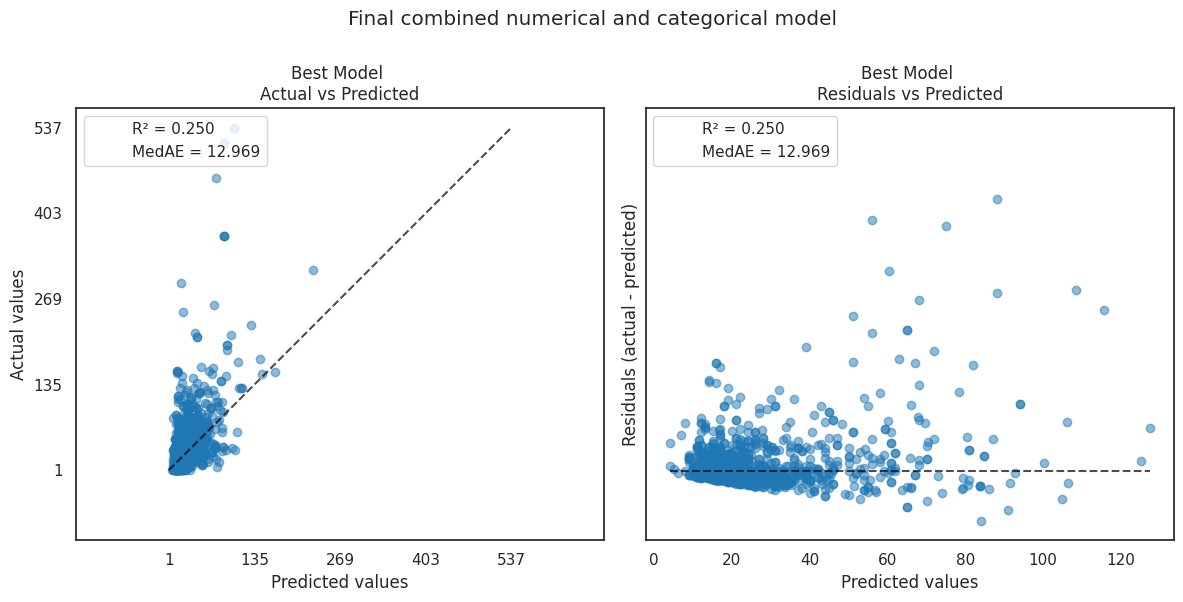

In [41]:
y_pred_test = final_model_pipeline.predict(X_test_sample)
plot_regression_performance(y_test_sample, y_pred_test, plot_title=title_desc)

In [33]:
X_train_sample.shape, y_train_sample.shape

((5604, 42), (5604,))

## Grid search parameter tuning on final model

## References

1. Target Transformation
   - https://scikit-learn.org/stable/auto_examples/compose/plot_transformed_target.html#sphx-glr-auto-examples-compose-plot-transformed-target-py
   - https://scikit-learn.org/stable/auto_examples/preprocessing/plot_target_encoder.html#sphx-glr-auto-examples-preprocessing-plot-target-encoder-py


2. Result Visualization
    - https://scikit-learn.org/stable/auto_examples/model_selection/plot_cv_predict.html#sphx-glr-auto-examples-model-selection-plot-cv-predict-py


3. Model improvement
    - https://scikit-learn.org/stable/auto_examples/ensemble/plot_stack_predictors.html#sphx-glr-auto-examples-ensemble-plot-stack-predictors-py


4. Model Interpretation and feature importance
    - https://scikit-learn.org/stable/auto_examples/inspection/plot_linear_model_coefficient_interpretation.html#sphx-glr-auto-examples-inspection-plot-linear-model-coefficient-interpretation-py
    - https://scikit-learn.org/stable/auto_examples/feature_selection/plot_rfe_with_cross_validation.html#sphx-glr-auto-examples-feature-selection-plot-rfe-with-cross-validation-py
    - https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance.html#sphx-glr-auto-examples-inspection-plot-permutation-importance-py


5. Using Bayesian Methods (Dint work so well)
    -  https://scikit-learn.org/stable/auto_examples/linear_model/plot_ard.html#sphx-glr-auto-examples-linear-model-plot-ard-py
  

6. Missing value imputation
    - https://scikit-learn.org/stable/auto_examples/impute/plot_missing_values.html
    - https://scikit-learn.org/stable/auto_examples/impute/plot_iterative_imputer_variants_comparison.html


7. Cross validation and grid search and Hyperparemeters tuning
    - https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_text_feature_extraction.html#sphx-glr-auto-examples-model-selection-plot-grid-search-text-feature-extraction-py
    - https://scikit-learn.org/stable/modules/grid_search.html#composite-grid-search
    - https://scikit-learn.org/stable/auto_examples/model_selection/plot_multi_metric_evaluation.html

8. Pipelines
    - https://scikit-learn.org/stable/modules/compose.html#transformed-target-regressor